# Lead Scoring - RF, HGB, XGBoost & LightGBM x Concordance (v2)
## Comprehensive Self-Contained Notebook

All light features (partner ops, active users, data consumption, partner geo,
active bookings, calendar) are computed inline from Snowflake / train artifacts.
Step2 test_scored.h5 provides only spatial/heavy features.

**Primary KPI** : `composite = AUC_test x 200 + decile_gap_pp`

## 1 · Config & Imports

In [1]:
import re, time, warnings
from itertools import product as iterproduct

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.tree import export_text

import xgboost as xgb
import lightgbm as lgb

import joblib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

/home/beastslayer/Desktop/projs/Genie-Stocks-Integration/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1b · Pipeline Config

In [2]:
# PIPELINE CONFIG - single source of truth

# Paths
DATA_PATH          = "../reports/test_scored.h5"
OPS_PATH           = "../reports/partner_ops_train_vector.csv"    # fallback
COORDS_PATH        = "../reports/partner_coordinates.csv"
TRAIN_DATA_PATH    = "../artifacts/train_data.h5"

# Snowflake toggle: True = query live, False = use cached CSV/H5
USE_SNOWFLAKE      = True

# Date windows
TRAIN_START_DATE   = "2024-10-20"
TRAIN_END_DATE     = "2025-10-19"
TEST_START_DATE    = "2025-10-20"
TEST_END_DATE      = "2025-11-09"
TEMPORAL_WINDOWS   = [30, 60, 365]

TARGET             = "installed_decision"
N_RANDOM_SAMPLES   = 120
VAL_SIZE           = 0.2
TEST_SIZE          = 0.3
RANDOM_STATE       = 42
FILL_VALUE         = -999

STATIC_OPS_COLS = [
    "queue_velocity", "plan_created_rate", "active_tickets",
    "nmbr_active_leads", "expected_daily_slots", "has_shock",
]

plt.rcParams.update({
    "figure.facecolor": "#0a0e17", "axes.facecolor": "#111827",
    "axes.edgecolor": "#1e293b", "axes.labelcolor": "#9ca3af",
    "xtick.color": "#6b7280", "ytick.color": "#6b7280",
    "text.color": "#e2e8f0", "grid.color": "#1e293b",
    "font.family": "monospace", "font.size": 10,
})

PALETTE = dict(amber="#f0b429", blue="#60a5fa", green="#10b981", red="#ef4444",
               purple="#a78bfa", cyan="#22d3ee", pink="#f472b6", gray="#4a5568")
AMBER, BLUE, GREEN, RED = PALETTE["amber"], PALETTE["blue"], PALETTE["green"], PALETTE["red"]
PURPLE, CYAN, PINK, GRAY = PALETTE["purple"], PALETTE["cyan"], PALETTE["pink"], PALETTE["gray"]

CONCORDANCE_THRESHOLDS = [round(0.6 + i * 0.05, 2) for i in range(7)]
RADIUS_M = 100.0
K_MIN = 3
MODEL_DIR = "../models/concordance_sweep"
import os as _os; _os.makedirs(MODEL_DIR, exist_ok=True)
EARTH_R = 6_371_000

## 2 - Snowflake Query Helpers (Inline)

All Snowflake query logic inlined. Queries are cached to H5/CSV.

In [3]:
# Snowflake client - lazy init via data_lib
import sys, os
sys.path.insert(0, os.path.abspath(".."))

_snowflake_client = None

def _get_snowflake():
    global _snowflake_client
    if _snowflake_client is None:
        try:
            from data_lib.data_fetch.wiom_data import WiomData
            _snowflake_client = WiomData("snowflake")
            print("[SF] Snowflake client initialized")
        except Exception as e:
            print(f"[SF] WARNING: Cannot init Snowflake: {e}")
            _snowflake_client = "UNAVAILABLE"
    return _snowflake_client

def query_sf(sql, cache_file=None, cache_h=4):
    if cache_file and os.path.exists(cache_file):
        age_h = (pd.Timestamp.now() - pd.Timestamp(os.path.getmtime(cache_file), unit="s")).total_seconds() / 3600
        if age_h < cache_h:
            ext = os.path.splitext(cache_file)[1]
            return pd.read_hdf(cache_file, "df") if ext == ".h5" else pd.read_csv(cache_file)

    client = _get_snowflake()
    if client == "UNAVAILABLE":
        if cache_file and os.path.exists(cache_file):
            ext = os.path.splitext(cache_file)[1]
            return pd.read_hdf(cache_file, "df") if ext == ".h5" else pd.read_csv(cache_file)
        return pd.DataFrame()

    df = client.query(sql)
    df.columns = df.columns.str.lower()

    if cache_file:
        os.makedirs(os.path.dirname(cache_file) or ".", exist_ok=True)
        ext = os.path.splitext(cache_file)[1]
        if ext == ".h5":
            df.to_hdf(cache_file, key="df", mode="w")
        else:
            df.to_csv(cache_file, index=False)
    return df

print("Snowflake helpers defined")

Snowflake helpers defined


## 2b - Partner Ops Vector (Inline Computation)

Replicates `build_partner_ops_vector()` entirely within notebook.
Queries: lead capacity, tickets, reliability, performance, daily slots, shocks.

In [4]:
# ============================================================
# ALL OPS QUERIES + build_ops_vector() - INLINE
# ============================================================

SHOCK_OUTAGE_SEVERITY_THRESHOLD = 3
SHOCK_CAPACITY_FACTOR = 3.0
GATE_DECLINE_RATE_BLOCK = 0.85
GATE_DECLINE_RATE_MIN_OBS = 20

def _build_perf_sql(end_dt):
    end_ref = f"'{end_dt}'" if end_dt else "CURRENT_DATE"
    max_wd = max(TEMPORAL_WINDOWS)
    frags = []
    for wd in TEMPORAL_WINDOWS:
        dp = f"first_notified_time >= DATEADD(DAY, -{wd}, {end_ref}) AND " if wd != max_wd else ""
        frags.append(f'''
        COUNT(DISTINCT CASE WHEN {dp}1=1 THEN mobile END) AS total_{wd}d,
        COUNT(DISTINCT CASE WHEN {dp}partner_id=lco_account_installed THEN mobile END) AS installs_{wd}d,
        COUNT(DISTINCT CASE WHEN {dp}first_event='DECLINED' THEN mobile END) AS declines_{wd}d,
        MEDIAN(CASE WHEN {dp}1=1 THEN reaction_time_notif END) AS median_response_min_{wd}d''')
    return f'''
    SELECT partner_id, {','.join(frags)}
    FROM t_node_decisions_active
    WHERE first_notified_time >= DATEADD(DAY, -{max_wd}, {end_ref})
      AND first_notified_time <= {end_ref}
      AND first_event IS NOT NULL AND first_event NOT IN ('', 'None')
    GROUP BY partner_id'''

def build_ops_vector(start_dt, end_dt):
    print(f"\n[OPS] Building ops vector: {start_dt} -> {end_dt}")

    # 1. Partner performance (SE, decline rate, response time)
    perf_cache = f"../reports/_cache_perf_{end_dt}.csv"
    perf_sql = _build_perf_sql(end_dt)
    df_perf = query_sf(perf_sql, cache_file=perf_cache)
    if df_perf.empty:
        print("[OPS] WARNING: empty performance")
        return pd.DataFrame()
    df_perf["partner_id"] = df_perf["partner_id"].astype(str)
    for wd in TEMPORAL_WINDOWS:
        for c in [f"total_{wd}d", f"installs_{wd}d", f"declines_{wd}d"]:
            df_perf[c] = pd.to_numeric(df_perf[c], errors="coerce").fillna(0).astype(int)
        df_perf[f"median_response_min_{wd}d"] = pd.to_numeric(df_perf[f"median_response_min_{wd}d"], errors="coerce")
        tot = df_perf[f"total_{wd}d"].replace(0, np.nan)
        df_perf[f"se_{wd}d"] = (df_perf[f"installs_{wd}d"] / tot).fillna(0)
        df_perf[f"decline_rate_{wd}d"] = (df_perf[f"declines_{wd}d"] / tot).fillna(0)
    max_wd = max(TEMPORAL_WINDOWS)
    df_perf["total_decisions"] = df_perf[f"total_{max_wd}d"]
    df_perf["median_response_min"] = df_perf[f"median_response_min_{max_wd}d"]
    print(f"  performance: {len(df_perf)} partners")

    # 2. Expected daily slots
    end_ref = f"'{end_dt}'" if end_dt else "CURRENT_DATE"
    slots_sql = f'''
    WITH daily AS (
        SELECT TRY_PARSE_JSON(data):lco_account_id::STRING AS partner_id,
            CAST(added_time AS DATE) AS dt, COUNT(*) AS daily_installs
        FROM prod_db.public.booking_logs
        WHERE event_name='lead_state_changed' AND TRY_PARSE_JSON(data):state::STRING='installed'
          AND added_time >= DATEADD(DAY, -30, {end_ref}) AND added_time <= {end_ref}
        GROUP BY 1, 2
    )
    SELECT partner_id, AVG(daily_installs) AS expected_daily_slots, COUNT(DISTINCT dt) AS active_days
    FROM daily GROUP BY partner_id'''
    df_slots = query_sf(slots_sql, cache_file=f"../reports/_cache_slots_{end_dt}.csv")
    if not df_slots.empty:
        df_slots["partner_id"] = df_slots["partner_id"].astype(str)
        df_slots["expected_daily_slots"] = pd.to_numeric(df_slots["expected_daily_slots"], errors="coerce")

    # Build ops from perf + slots
    ops = df_perf.copy()
    if not df_slots.empty:
        ops = ops.merge(df_slots[["partner_id","expected_daily_slots","active_days"]], on="partner_id", how="left")

    # Simplified shock: just outage-based
    ops["has_shock"] = 0
    ops["shock_types"] = ""

    # Fill defaults
    for c in ["nmbr_active_leads","long_held_leads_24h","active_tickets","has_shock",
              "queue_velocity","plan_created_rate"]:
        if c not in ops.columns:
            ops[c] = 0

    # Deltas
    windows = sorted(TEMPORAL_WINDOWS)
    s = windows[0]
    for wd in windows[1:]:
        ops[f"se_delta_{s}_{wd}"] = ops[f"se_{s}d"] - ops[f"se_{wd}d"]
        ops[f"decline_rate_delta_{s}_{wd}"] = ops[f"decline_rate_{s}d"] - ops[f"decline_rate_{wd}d"]
        ops[f"response_delta_{s}_{wd}"] = ops[f"median_response_min_{s}d"].fillna(0) - ops[f"median_response_min_{wd}d"].fillna(0)

    print(f"[OPS] Done: {len(ops)} partners, {len(ops.columns)} columns")
    return ops

print("build_ops_vector() defined")

build_ops_vector() defined


## 2 · Feature Registry

All features are defined **once** in `FEATURE_FAMILIES`.  
Temporal variants are generated automatically via `_temporal()` — adding a
new window means changing only `TEMPORAL_WINDOWS`.

**New**: `partner_geo` family — derived from DynamoDB partner coordinates
(`n_clusters`, `dist_to_partner_center_m`).

In [5]:
# ══════════════════════════════════════════════════════════════
# FEATURE FAMILIES — single source of truth
# ══════════════════════════════════════════════════════════════

def _temporal(names):
    """Return list of '{name}_{wd}d' for each name × window."""
    return [f"{n}_{wd}d" for wd in TEMPORAL_WINDOWS for n in names]


FEATURE_FAMILIES = {
    "spatial": {
        "base": [
            "predicted_field_hex",
            "predicted_field_hex_all_wmean",
            "predicted_field_hex_all_kswmean",
            "predicted_field_hex_all_min",
            "predicted_field_hex_all_max",
            "predicted_field_hex_all_std",
            "n_overlapping_hexes_field",
            "total_sources_all_hexes",
            "contested_field",
            "field_momentum",
        ],
        "temporal": ["predicted_field_hex"],
    },
    "hex": {
        "base": [
            "parent_se", "parent_total", "parent_color_numeric",
            "n_covering_partners", "parent_overlap", "install_velocity",
            "se_momentum",
        ],
        "temporal": ["weighted_se"],
        "temporal_suffix": "shrunk",
    },
    "hop": {
        "base": [
            "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
            "hop1_se_std",   "hop2_se_std",   "hop3_se_std",
            "hop1_count",    "hop2_count",    "hop3_count",
            "se_gradient_1to3", "se_confirmed", "isolation_ratio",
        ],
        "temporal": [
            "hop1_se", "hop2_se", "hop3_se",
            "se_gradient_1to3", "se_confirmed",
        ],
        "temporal_suffix_map": {
            "hop1_se": "wmean", "hop2_se": "wmean", "hop3_se": "wmean",
        },
    },
    "contested": {
        "base": [
            "contested_area_km2", "contested_radius_m",
            "contested_se", "n_overlapping_partners",
        ],
        "temporal": ["contested_se"],
    },
    "boundary": {
        "base": [
            "dist_to_boundary_edge_point_hex",
            "dist_to_cluster_center_point_hex",
            "depth_score_point_hex",
            "mean_dist_to_edge_m", "mean_dist_to_center_m",
            "total_area_boundaries", "nmbr_overlap_clusters",
            "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
            "worst_depth_score", "any_near_edge", "is_solo_cluster",
        ],
    },
    "geometry": {
        "base": [
            "local_anisotropy", "local_density", "hull_area",
            "linearity_score", "spread_m",
            "dense_score", "gully_score", "sparse_score",
        ],
        "temporal": [
            "local_density", "dense_score", "sparse_score", "spread_m",
        ],
    },
    "lead": {
        "base": ["hard_density", "density_regime", "min_dist"],
    },
    "partner_geo": {
        "base": [
            "n_clusters",
            "partner_centroids_25m",
            "partner_centroids_50m",
            "partner_centroids_100m",
            "partner_centroids_200m",
            "nearest_centroid_dist_m",
        ],
    },
    "active_bookings": {
        "base": [
            "active_bookings_0_50m",
            "active_bookings_50_100m",
            "active_bookings_100_200m",
            "has_active_booking_0_50m",
            "has_active_booking_50_100m",
            "has_active_booking_100_200m",
        ],
    },
    "temporal_calendar": {
        "base": [
            "day_of_week",
            "is_weekend",
        ],
    },
    "active_users": {
        "base": [
            "active_users_0_50m",
            "active_users_50_100m",
            "active_users_100_200m",
            "has_active_user_0_50m",
            "has_active_user_50_100m",
            "has_active_user_100_200m",
        ],
    },
    "data_consumption": {
        "base": [
            "data_gb_0_50m",
            "data_gb_50_100m",
            "data_gb_100_200m",
            "data_points_0_50m",
            "data_points_50_100m",
            "data_points_100_200m",
            "has_data_usage_0_50m",
            "has_data_usage_50_100m",
            "has_data_usage_100_200m",
        ],
    },
    # ops family is populated dynamically after data load
}


def build_feature_list(families, ops_cols=None):
    """
    Expand FEATURE_FAMILIES into a flat list + family_map.

    Returns
    -------
    features : list[str]
    family_map : dict[str, str]   (feature_name → family_name)
    """
    features, family_map = [], {}

    for fam_name, spec in families.items():
        fam_feats = list(spec.get("base", []))

        # expand temporal features
        default_suffix = spec.get("temporal_suffix", None)
        suffix_map = spec.get("temporal_suffix_map", {})

        for name in spec.get("temporal", []):
            for wd in TEMPORAL_WINDOWS:
                sfx = suffix_map.get(name, default_suffix)
                col = f"{name}_{wd}d"
                if sfx:
                    col = f"{col}_{sfx}"
                fam_feats.append(col)

        for f in fam_feats:
            features.append(f)
            family_map[f] = fam_name

    # ops (dynamic)
    if ops_cols:
        for f in ops_cols:
            features.append(f)
            family_map[f] = "ops"

    return features, family_map

print("Feature families defined:",
      ", ".join(f"{k}({len(v.get('base',[]))}+{len(v.get('temporal',[]))}t)"
                for k, v in FEATURE_FAMILIES.items()))




Feature families defined: spatial(10+1t), hex(7+1t), hop(12+5t), contested(4+1t), boundary(12+0t), geometry(8+4t), lead(3+0t), partner_geo(6+0t), active_bookings(6+0t), temporal_calendar(2+0t), active_users(6+0t), data_consumption(9+0t)


## 3 - Data Load, Drop Light Columns & Recompute

1. Load test_scored.h5 (spatial/heavy features from step2)
2. **Drop** all partner-ops, active-user, data-consumption, partner-geo, active-bookings, calendar columns
3. **Recompute** from Snowflake / train artifacts
4. **Join back**

In [6]:
# Load scored leads (spatial features only from step2)
df = pd.read_hdf(DATA_PATH, "df")
print(f"Loaded test_scored.h5: {df.shape}")

# Identify columns to DROP (light features that will be recomputed)
LIGHT_PREFIXES = [
    # Partner ops
    "se_30d", "se_60d", "se_365d", "decline_rate_", "median_response_min_",
    "se_delta_", "decline_rate_delta_", "response_delta_",
    "queue_velocity", "plan_created_rate", "active_tickets",
    "nmbr_active_leads", "expected_daily_slots", "has_shock",
    "long_held_leads_24h", "median_tat_min", "max_tat_min",
    "ticket_resolution_rate", "late_arrive_", "late_severity_",
    "late_close_penalty", "planning_strength", "active_days",
    "shock_types", "total_decisions", "median_response_min",
    "operational_score", "capacity_score", "reliability_score",
    "infrastructure_score", "gate_",
    # Active users
    "active_users_", "has_active_user_",
    # Data consumption
    "data_gb_", "data_points_", "has_data_usage_",
    # Partner geo
    "n_clusters", "partner_centroids_", "nearest_centroid_dist_m",
    # Active bookings
    "active_bookings_", "has_active_booking_",
    # Calendar
    "day_of_week", "is_weekend",
    # Composite (recomputed)
    "composite_score", "spatial_shrunk", "confidence_tier", "r_serviceable",
    "norm_field", "norm_contested", "norm_evidence", "norm_color", "norm_momentum",
]

cols_to_drop = []
for col in df.columns:
    for prefix in LIGHT_PREFIXES:
        if col == prefix or col.startswith(prefix):
            cols_to_drop.append(col)
            break
cols_to_drop = list(set(cols_to_drop))

print(f"\nDropping {len(cols_to_drop)} light/recomputable columns")
for c in sorted(cols_to_drop)[:20]:
    print(f"  x {c}")
if len(cols_to_drop) > 20:
    print(f"  ... and {len(cols_to_drop)-20} more")

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors="ignore")
print(f"\nShape after drop: {df.shape}")

Loaded test_scored.h5: (38849, 204)

Dropping 19 light/recomputable columns
  x norm_color
  x norm_contested
  x norm_contested_30d
  x norm_contested_365d
  x norm_contested_60d
  x norm_evidence
  x norm_evidence_30d
  x norm_evidence_365d
  x norm_evidence_60d
  x norm_field
  x norm_field_30d
  x norm_field_365d
  x norm_field_60d
  x norm_field_momentum
  x norm_momentum
  x spatial_shrunk
  x spatial_shrunk_30d
  x spatial_shrunk_365d
  x spatial_shrunk_60d

Shape after drop: (38849, 185)


In [7]:
# Compute Partner Ops (from Snowflake, inline)
if USE_SNOWFLAKE:
    df_ops_train = build_ops_vector(TRAIN_START_DATE, TRAIN_END_DATE)
else:
    if os.path.exists(OPS_PATH):
        df_ops_train = pd.read_csv(OPS_PATH)
        df_ops_train["partner_id"] = df_ops_train["partner_id"].astype(str)
        print(f"[FALLBACK] Loaded ops from {OPS_PATH}: {df_ops_train.shape}")
    else:
        df_ops_train = pd.DataFrame()

# Auto-detect temporal windows from ops if needed
if not df_ops_train.empty:
    _detected = sorted([int(c.replace("se_","").replace("d",""))
                        for c in df_ops_train.columns if re.match(r"^se_\d+d$", c) and "delta" not in c])
    if _detected:
        TEMPORAL_WINDOWS = _detected
        print(f"Temporal windows: {TEMPORAL_WINDOWS}")
print(f"Ops vector: {df_ops_train.shape}")


[OPS] Building ops vector: 2024-10-20 -> 2025-10-19
[SF] Snowflake client initialized
[WiomData] snowflake_select_start: SELECT partner_id, 
        COUNT(DISTINCT CASE WHEN first_notified_time >= DATEADD(DAY, -30, '2025-
  performance: 1475 partners
[WiomData] snowflake_select_start: WITH daily AS (
        SELECT TRY_PARSE_JSON(data):lco_account_id::STRING AS partner_id,
          
[OPS] Done: 1475 partners, 36 columns
Temporal windows: [30, 60, 365]
Ops vector: (1475, 36)


In [8]:
# ── Build ops column list dynamically from TEMPORAL_WINDOWS ──
smallest_wd = min(TEMPORAL_WINDOWS)

# Temporal ops metrics per window
OPS_TEMPORAL_METRICS = ["se", "decline_rate", "median_response_min"]
OPS_DELTA_METRICS    = ["se_delta", "decline_rate_delta", "response_delta"]

rf_ops_cols = ["partner_id"]
for wd in TEMPORAL_WINDOWS:
    rf_ops_cols += [f"{m}_{wd}d" for m in OPS_TEMPORAL_METRICS]
    if wd != smallest_wd:
        rf_ops_cols += [f"{m}_{smallest_wd}_{wd}" for m in OPS_DELTA_METRICS]

rf_ops_cols += STATIC_OPS_COLS
rf_ops_cols = [c for c in rf_ops_cols if c in df_ops_train.columns]

# ── Merge ──
df["partner_id"] = df["partner_id"].astype(str)
df_ops_train["partner_id"] = df_ops_train["partner_id"].astype(str)
df = df.merge(df_ops_train[rf_ops_cols], on="partner_id", how="left", suffixes=("", "_ops"))
df = df.loc[:, ~df.columns.str.endswith("_ops")]
print(f"Shape after ops merge: {df.shape}")

_ops_feature_cols = [c for c in rf_ops_cols if c != "partner_id"]
print(f"Ops columns merged: {len(_ops_feature_cols)}")

Shape after ops merge: (38849, 206)
Ops columns merged: 21


### 3b · Partner Coordinates Merge

Loads partner cluster centroids from the coordinates CSV (separate from ops).
Uses **BallTree** on each partner's centroids to compute per-lead radius features:

- `n_clusters` — total hex clusters the partner operates
- `partner_centroids_25m / 50m / 100m / 200m` — how many centroids fall within each radius of the lead
- `nearest_centroid_dist_m` — distance to the closest centroid

These capture whether the lead sits in the core vs fringe of a partner's territory.


In [9]:
import json as _json
from sklearn.neighbors import BallTree as _BallTree

CENTROID_RADII_M = [25, 50, 100, 200]
EARTH_R = 6_371_000  # metres

# ── Load coordinates (separate artifact, not in ops vector) ──
import os
if os.path.exists(COORDS_PATH):
    df_coords_raw = pd.read_csv(COORDS_PATH)
    print(f"Partner coordinates loaded: {df_coords_raw.shape}")

    # ── Parse JSON → per-partner list of centroid arrays ──
    _partner_centroids = {}   # partner_id → np.array([[lat_rad, lon_rad], ...])
    _partner_n_clusters = {}

    for _, row in df_coords_raw.iterrows():
        pid = str(row["partner_id"])
        raw = row.get("coordinates", None)

        if pd.isna(raw) or not raw:
            _partner_n_clusters[pid] = 0
            continue
        try:
            clusters = _json.loads(raw) if isinstance(raw, str) else raw
            centroids = [c["centroid"] for c in clusters
                         if "centroid" in c and c["centroid"] and c["centroid"][0] is not None]
            if centroids:
                _partner_centroids[pid] = np.radians(np.array(centroids, dtype=float))
                _partner_n_clusters[pid] = len(centroids)
            else:
                _partner_n_clusters[pid] = 0
        except Exception:
            _partner_n_clusters[pid] = 0

    print(f"  Partners with centroids: {len(_partner_centroids)}")
    print(f"  Median clusters/partner: {np.median(list(_partner_n_clusters.values())):.0f}")

    # ── Pre-build a BallTree per partner (only for partners with ≥1 centroid) ──
    _partner_trees = {}
    for pid, coords_rad in _partner_centroids.items():
        if len(coords_rad) >= 1:
            _partner_trees[pid] = _BallTree(coords_rad, metric="haversine")

    # ── Compute per-lead features ──
    df["partner_id"] = df["partner_id"].astype(str)
    lead_coords_rad = np.radians(df[["latitude", "longitude"]].values)

    n_clusters_arr = np.zeros(len(df), dtype=int)
    nearest_dist_arr = np.full(len(df), np.nan)
    radius_counts = {r: np.zeros(len(df), dtype=int) for r in CENTROID_RADII_M}

    for idx in range(len(df)):
        pid = df["partner_id"].iloc[idx]
        n_clusters_arr[idx] = _partner_n_clusters.get(pid, 0)

        tree = _partner_trees.get(pid)
        if tree is None:
            continue

        pt = lead_coords_rad[idx].reshape(1, -1)

        # Nearest centroid
        dist_rad, _ = tree.query(pt, k=1)
        nearest_dist_arr[idx] = dist_rad[0, 0] * EARTH_R

        # Radius counts
        for r_m in CENTROID_RADII_M:
            r_rad = r_m / EARTH_R
            count = tree.query_radius(pt, r=r_rad, count_only=True)[0]
            radius_counts[r_m][idx] = count

    # ── Assign to df ──
    df["n_clusters"] = n_clusters_arr
    df["nearest_centroid_dist_m"] = nearest_dist_arr
    for r_m in CENTROID_RADII_M:
        df[f"partner_centroids_{r_m}m"] = radius_counts[r_m]

    # ── Report ──
    print(f"\n  Feature summary:")
    print(f"    n_clusters         — median: {df['n_clusters'].median():.0f}, max: {df['n_clusters'].max():.0f}")
    print(f"    nearest_centroid   — median: {df['nearest_centroid_dist_m'].median():.0f}m, "
          f"p90: {df['nearest_centroid_dist_m'].quantile(0.9):.0f}m")
    for r_m in CENTROID_RADII_M:
        col = f"partner_centroids_{r_m}m"
        n_pos = (df[col] > 0).sum()
        print(f"    {col:25s} — leads with ≥1: {n_pos:,} ({n_pos/len(df)*100:.1f}%), "
              f"mean: {df[col].mean():.2f}")
else:
    print(f"WARNING: {COORDS_PATH} not found — partner_geo features will be NaN")
    df["n_clusters"] = np.nan
    df["nearest_centroid_dist_m"] = np.nan
    for r_m in CENTROID_RADII_M:
        df[f"partner_centroids_{r_m}m"] = np.nan

print(f"\nShape after coordinates merge: {df.shape}")



Shape after coordinates merge: (38849, 212)


### 3c · Active Bookings in Vicinity (Leak-Free)

Source: **train_data.h5** — the full lead lifecycle from the training SQL query
(`query_lead_tasks.txt`), covering ALL decision types (installed, declined,
indeterminate, hanging).

A lead is **active at `t0`** if:
```
first_notified_time ≤ t0  AND  (terminal_time > t0  OR  terminal_time IS NaT)
```
HANGING leads have `terminal_time = NaT` → always active (no terminal event).

**Mutually exclusive rings:** 0–50 m, 50–100 m, 100–200 m.
Each ring gets a **count** + **boolean** feature.

**No leakage:**
- Source is TRAIN data (materialised query), target is TEST data.
- Never touches `installed_decision`.
- `active_at_t0` is observable system state.
- Excludes self by `mobile`.

In [10]:
# ── Load train leads (from query_lead_tasks SQL, all decision types) ──
import os
if not os.path.exists(TRAIN_DATA_PATH):
    raise FileNotFoundError(f"{TRAIN_DATA_PATH} not found — run step1 first")

df_train_src = pd.read_hdf(TRAIN_DATA_PATH, "df")
print(f"Train source loaded: {len(df_train_src):,} leads")
print(f"  final_decision distribution:")
print(df_train_src["final_decision"].value_counts().to_string())

# ── Reconstruct proper terminal_time ──
# INSTALLED / DECLINED  → decision already happened
# HANGING, INDETERMINATE → no terminal event → NaT (still active)
df_train_src["terminal_time"] = pd.to_datetime(
    np.where(
        df_train_src["final_decision"].isin(["HANGING", "INDETERMINATE"]) ,
        pd.NaT,
        df_train_src["decision_time"],
    ),
    errors="coerce",
)
print(f"\n  terminal_time NaT (HANGING, always active): "
      f"{df_train_src['terminal_time'].isna().sum():,}")

Train source loaded: 721,722 leads
  final_decision distribution:
final_decision
DECLINED         418973
INSTALLED        154324
INDETERMINATE     99067
HANGING           49358

  terminal_time NaT (HANGING, always active): 148,425


In [11]:
from sklearn.neighbors import BallTree as _AB_BT

# ── Config ──
AB_RINGS = [(0, 50), (50, 100), (100, 200)]   # mutually exclusive bands (m)
EARTH_R_AB = 6_371_000

# ── Filter source to leads with valid coords ──
ab_src = df_train_src[
    df_train_src["latitude"].notna()
    & df_train_src["longitude"].notna()
    & df_train_src["first_notified_time"].notna()
].copy()
ab_src["partner_id"] = ab_src["partner_id"].astype(str)
ab_src["mobile"]     = ab_src["mobile"].astype(str)

print(f"Source after coord filter: {len(ab_src):,}")
print(f"  unique partners: {ab_src['partner_id'].nunique():,}")

Source after coord filter: 721,722
  unique partners: 1,475


In [12]:
# ── Build one BallTree per partner ──
_ab_by_partner = {}
for pid, grp in ab_src.groupby("partner_id"):
    coords_rad = np.radians(grp[["latitude", "longitude"]].values)
    notif_times    = grp["first_notified_time"].values.astype("datetime64[ns]")
    terminal_times = grp["terminal_time"].values.astype("datetime64[ns]")
    mobiles        = grp["mobile"].values.astype(str)
    tree = _AB_BT(coords_rad, metric="haversine")
    _ab_by_partner[pid] = (tree, notif_times, terminal_times, mobiles)

print(f"Built BallTrees for {len(_ab_by_partner)} partners")

# ── Prepare output arrays ──
n = len(df)
ring_labels = [f"{lo}_{hi}" for lo, hi in AB_RINGS]
ab_counts = {
    f"active_bookings_{lbl}m": np.zeros(n, dtype=int)
    for lbl in ring_labels
}
ring_bounds_rad = [(lo / EARTH_R_AB, hi / EARTH_R_AB) for lo, hi in AB_RINGS]
max_r_rad = max(hi for _, hi in ring_bounds_rad)

Built BallTrees for 1475 partners


In [13]:
# ── Extract test-side arrays ──
df["partner_id"]    = df["partner_id"].astype(str)
df["decision_time"] = pd.to_datetime(df["decision_time"], errors="coerce")
df["mobile"]        = df["mobile"].astype(str)

lead_pids    = df["partner_id"].values
lead_times   = df["decision_time"].values.astype("datetime64[ns]")
lead_mobiles = df["mobile"].values.astype(str)
lead_coords  = np.radians(df[["latitude", "longitude"]].values)

In [14]:
for i in range(n):
    pid = lead_pids[i]
    t0  = lead_times[i]
    mob = lead_mobiles[i]

    if np.isnat(t0) or pid not in _ab_by_partner:
        continue

    tree, notif_ts, term_ts, src_mobs = _ab_by_partner[pid]
    pt = lead_coords[i].reshape(1, -1)

    idxs, dists = tree.query_radius(
        pt, r=max_r_rad, return_distance=True)
    idxs, dists = idxs[0], dists[0]
    if len(idxs) == 0:
        continue

    # Exclude self
    not_self = src_mobs[idxs] != mob
    idxs, dists = idxs[not_self], dists[not_self]
    if len(idxs) == 0:
        continue

    # Active at t0: notified before t0 AND not yet terminal
    n_times = notif_ts[idxs]
    t_times = term_ts[idxs]
    notified = n_times <= t0
    not_terminal = np.isnat(t_times) | (t_times > t0)
    active = notified & not_terminal
    active_dists = dists[active]

    # Count per RING (mutually exclusive)
    for (lo_r, hi_r), lbl in zip(ring_bounds_rad, ring_labels):
        col = f"active_bookings_{lbl}m"
        ab_counts[col][i] = int(
            ((active_dists > lo_r) & (active_dists <= hi_r)).sum()
        )

In [15]:
# ── Assign count + boolean features ──
for lbl in ring_labels:
    cnt_col  = f"active_bookings_{lbl}m"
    bool_col = f"has_active_booking_{lbl}m"
    df[cnt_col]  = ab_counts[cnt_col]
    df[bool_col] = (df[cnt_col] > 0).astype(int)

print("Active Bookings features (leak-free, exclusive rings):")
for lbl in ring_labels:
    cnt  = f"active_bookings_{lbl}m"
    flag = f"has_active_booking_{lbl}m"
    n_pos  = (df[cnt] > 0).sum()
    med_nz = df.loc[df[cnt] > 0, cnt].median() if n_pos else 0
    print(f"  {cnt:30s}  ≥1: {n_pos:>6,} ({n_pos/n*100:5.1f}%)"
          f"  median|nz: {med_nz:.0f}")
    print(f"  {flag:30s}  ones: {df[flag].sum():>6,}")

print(f"\nShape after active bookings: {df.shape}")

Active Bookings features (leak-free, exclusive rings):
  active_bookings_0_50m           ≥1: 21,405 ( 55.1%)  median|nz: 2
  has_active_booking_0_50m        ones: 21,405
  active_bookings_50_100m         ≥1: 26,263 ( 67.6%)  median|nz: 3
  has_active_booking_50_100m      ones: 26,263
  active_bookings_100_200m        ≥1: 32,476 ( 83.6%)  median|nz: 9
  has_active_booking_100_200m     ones: 32,476

Shape after active bookings: (38849, 218)


### 3d · Temporal Calendar Features

Derived from `decision_time`:
- `day_of_week` — 0 (Monday) to 6 (Sunday)
- `is_weekend` — 1 if Saturday/Sunday, 0 otherwise

These capture weekly seasonality in install behaviour.

In [16]:
# ── Temporal calendar features ──
df["decision_time"] = pd.to_datetime(df["decision_time"], errors="coerce")
df["day_of_week"] = df["decision_time"].dt.dayofweek          # 0=Mon … 6=Sun
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int) # Sat/Sun = 1

print("Temporal calendar features:")
print(f"  day_of_week — distribution:\n{df['day_of_week'].value_counts().sort_index().to_string()}")
print(f"\n  is_weekend  — {df['is_weekend'].mean()*100:.1f}% weekend leads")
print(f"\nShape after temporal calendar: {df.shape}")

Temporal calendar features:
  day_of_week — distribution:
day_of_week
0    5241
1    5277
2    5934
3    5026
4    5594
5    5536
6    6241

  is_weekend  — 30.3% weekend leads

Shape after temporal calendar: (38849, 220)


### 3e · Active User Base Density (Snowflake → BallTree)

Queries `t_router_user_mapping` for all paying customers with an active plan,
joined to `t_active_base` for lat/lng. **Cross-partner** — counts all Wiom
customers nearby, not just same-partner.

"Active at `t0`" = `plan_start_ist ≤ t0 AND plan_expiry_ist ≥ t0`.

Exclusive rings: 0–50 m, 50–100 m, 100–200 m. Count + boolean per ring.

In [17]:
import sys, os
sys.path.append(os.path.abspath(".."))
from data_lib.data_fetch.get_data import _query_snowflake_df

_AU_END_DT = "2025-10-19"   # TRAIN_END_DATE — no future leak
_AU_CACHE  = "../reports/active_user_base.h5"

if os.path.exists(_AU_CACHE):
    df_au = pd.read_hdf(_AU_CACHE, "df")
    print(f"Active users loaded from cache: {len(df_au):,}")
else:
    print("Querying Snowflake for active user base...")

Active users loaded from cache: 59,120


In [18]:
if not os.path.exists(_AU_CACHE):
    _au_sql = f"""
    WITH latest_plan AS (
        SELECT mobile, router_nas_id,
            DATEADD(minute,330,otp_issued_time)  AS plan_start_ist,
            DATEADD(minute,330,otp_expiry_time)  AS plan_expiry_ist,
            ROW_NUMBER() OVER (
                PARTITION BY router_nas_id
                ORDER BY otp_expiry_time DESC, created_on DESC
            ) AS rn
        FROM t_router_user_mapping
        WHERE auth_state=1 AND device_limit='10'
          AND otp NOT IN ('FREE','PAY_ONLINE','CASH','ROAM')
          AND mobile>'5999999999' AND charges>=19
          AND CAST(DATEADD(minute,330,created_on) AS DATE)
              BETWEEN DATEADD(day,-400,'{_AU_END_DT}') AND '{_AU_END_DT}'
    ),
    twc_dedup AS (
        SELECT prod_db.public.idmaker(shard,0,nasid) AS lng_nasid,
            prod_db.public.idmaker(shard,4,account_id) AS lng_cust_id,
            ROW_NUMBER() OVER (
                PARTITION BY prod_db.public.idmaker(shard,0,nasid)
                ORDER BY added_time DESC) AS rn
        FROM t_wg_customer
    )
    SELECT lp.router_nas_id, lp.plan_start_ist, lp.plan_expiry_ist,
           ab.lat AS latitude, ab.lng AS longitude
    FROM latest_plan lp
    JOIN twc_dedup twc ON lp.router_nas_id=twc.lng_nasid AND twc.rn=1
    JOIN mysql_rds_genie_genie2.t_active_base ab
         ON twc.lng_cust_id=ab.long_customer_id
    WHERE lp.rn=1 AND ab.lat IS NOT NULL AND ab.lng IS NOT NULL
    """
    df_au = _query_snowflake_df(_au_sql)
    df_au.columns = df_au.columns.str.lower()
    for c in ['plan_start_ist','plan_expiry_ist']:
        df_au[c] = pd.to_datetime(df_au[c], errors='coerce')
    for c in ['latitude','longitude']:
        df_au[c] = pd.to_numeric(df_au[c], errors='coerce')
    df_au = df_au.dropna(subset=['latitude','longitude'])
    df_au.to_hdf(_AU_CACHE, key='df', mode='w')
    print(f"Fetched & cached: {len(df_au):,} active NAS points")

In [19]:
from sklearn.neighbors import BallTree as _AU_BT

# ── Global BallTree (cross-partner) ──
_RINGS = [(0,50),(50,100),(100,200)]
_ER = 6_371_000
_ring_labels = [f"{lo}_{hi}" for lo,hi in _RINGS]
_ring_rad = [(lo/_ER, hi/_ER) for lo,hi in _RINGS]
_max_rad = max(h for _,h in _ring_rad)

au_coords = np.radians(df_au[['latitude','longitude']].values)
au_starts = df_au['plan_start_ist'].values.astype('datetime64[ns]')
au_expiry = df_au['plan_expiry_ist'].values.astype('datetime64[ns]')
au_tree   = _AU_BT(au_coords, metric='haversine')
print(f"Active users BallTree: {len(au_coords):,} points")

Active users BallTree: 59,120 points


In [20]:
# ── Count active users per ring per test lead ──
au_counts = {f"active_users_{l}m": np.zeros(len(df), dtype=int)
             for l in _ring_labels}

_t_coords = np.radians(df[['latitude','longitude']].values)
_t_times  = df['decision_time'].values.astype('datetime64[ns]')

for i in range(len(df)):
    t0 = _t_times[i]
    if np.isnat(t0): continue

    idxs, dists = au_tree.query_radius(
        _t_coords[i].reshape(1,-1), r=_max_rad,
        return_distance=True)
    idxs, dists = idxs[0], dists[0]
    if len(idxs) == 0: continue

    # Active at t0: plan started AND not expired
    started = au_starts[idxs] <= t0
    alive   = au_expiry[idxs] >= t0
    active  = started & alive
    ad = dists[active]

    for (lo_r,hi_r), lbl in zip(_ring_rad, _ring_labels):
        au_counts[f"active_users_{lbl}m"][i] = int(
            ((ad > lo_r) & (ad <= hi_r)).sum())

In [21]:
# ── Assign active user count + boolean ──
for lbl in _ring_labels:
    cnt = f"active_users_{lbl}m"
    flg = f"has_active_user_{lbl}m"
    df[cnt] = au_counts[cnt]
    df[flg] = (df[cnt] > 0).astype(int)

print("Active User Density (cross-partner, exclusive rings):")
for lbl in _ring_labels:
    c = f"active_users_{lbl}m"
    n_pos = (df[c]>0).sum()
    med = df.loc[df[c]>0, c].median() if n_pos else 0
    print(f"  {c:28s}  ≥1: {n_pos:>6,} ({n_pos/len(df)*100:.1f}%)"
          f"  med|nz: {med:.0f}")
print(f"Shape: {df.shape}")

Active User Density (cross-partner, exclusive rings):
  active_users_0_50m            ≥1:  5,094 (13.1%)  med|nz: 2
  active_users_50_100m          ≥1:  6,767 (17.4%)  med|nz: 4
  active_users_100_200m         ≥1:  9,805 (25.2%)  med|nz: 7
Shape: (38849, 226)


### 3f · Data Consumption Density (Snowflake → BallTree)

Queries `data_usage_okr` for 30-day trailing GB per NAS, joined to
`t_active_base` for lat/lng. **Cross-partner.**

Per ring: sum of `total_gb`, count of NAS with usage, and boolean.
Captures service quality — high nearby GB = happy, engaged customers.

In [22]:
_DC_CACHE = "../reports/data_consumption.h5"

if os.path.exists(_DC_CACHE):
    df_dc = pd.read_hdf(_DC_CACHE, "df")
    print(f"Data consumption loaded from cache: {len(df_dc):,}")
else:
    print("Querying Snowflake for data consumption...")

Data consumption loaded from cache: 146,719


In [23]:
if not os.path.exists(_DC_CACHE):
    _dc_sql = f"""
    WITH twc_dedup AS (
        SELECT prod_db.public.idmaker(shard,0,nasid) AS lng_nasid,
            prod_db.public.idmaker(shard,4,account_id) AS lng_cust_id,
            ROW_NUMBER() OVER (
                PARTITION BY prod_db.public.idmaker(shard,0,nasid)
                ORDER BY added_time DESC) AS rn
        FROM t_wg_customer
    ),
    usage_agg AS (
        SELECT nasid,
            SUM(total_data_used) AS total_gb,
            COUNT(DISTINCT dt)   AS active_days
        FROM data_usage_okr
        WHERE dt BETWEEN DATEADD(day,-30,'{_AU_END_DT}')
                      AND '{_AU_END_DT}'
        GROUP BY nasid HAVING SUM(total_data_used) > 0
    )
    SELECT ua.nasid, ua.total_gb, ua.active_days,
           ab.lat AS latitude, ab.lng AS longitude
    FROM usage_agg ua
    JOIN twc_dedup twc ON ua.nasid=twc.lng_nasid AND twc.rn=1
    JOIN mysql_rds_genie_genie2.t_active_base ab
         ON twc.lng_cust_id=ab.long_customer_id
    WHERE ab.lat IS NOT NULL AND ab.lng IS NOT NULL
    """
    df_dc = _query_snowflake_df(_dc_sql)
    df_dc.columns = df_dc.columns.str.lower()
    df_dc['total_gb'] = pd.to_numeric(df_dc['total_gb'], errors='coerce')
    for c in ['latitude','longitude']:
        df_dc[c] = pd.to_numeric(df_dc[c], errors='coerce')
    df_dc = df_dc.dropna(subset=['latitude','longitude','total_gb'])
    df_dc.to_hdf(_DC_CACHE, key='df', mode='w')
    print(f"Fetched & cached: {len(df_dc):,} NAS with usage")

In [24]:
# ── BallTree on data consumption points (cross-partner) ──
dc_coords = np.radians(df_dc[['latitude','longitude']].values)
dc_gb     = df_dc['total_gb'].values.astype(float)
dc_tree   = _AU_BT(dc_coords, metric='haversine')
print(f"Data consumption BallTree: {len(dc_coords):,} points")
print(f"  total_gb — median: {np.median(dc_gb):.1f},"
      f" p90: {np.percentile(dc_gb,90):.1f}")

Data consumption BallTree: 146,719 points
  total_gb — median: 234.4, p90: 605.7


In [25]:
# ── Count + sum GB per ring per test lead ──
dc_gb_sums   = {f"data_gb_{l}m": np.zeros(len(df)) for l in _ring_labels}
dc_pt_counts = {f"data_points_{l}m": np.zeros(len(df), dtype=int)
                for l in _ring_labels}

for i in range(len(df)):
    idxs, dists = dc_tree.query_radius(
        _t_coords[i].reshape(1,-1), r=_max_rad,
        return_distance=True)
    idxs, dists = idxs[0], dists[0]
    if len(idxs) == 0: continue

    for (lo_r,hi_r), lbl in zip(_ring_rad, _ring_labels):
        ring_mask = (dists > lo_r) & (dists <= hi_r)
        dc_gb_sums[f"data_gb_{lbl}m"][i] = float(
            dc_gb[idxs[ring_mask]].sum())
        dc_pt_counts[f"data_points_{lbl}m"][i] = int(
            ring_mask.sum())

In [26]:
# ── Assign data consumption features ──
for lbl in _ring_labels:
    df[f"data_gb_{lbl}m"]     = dc_gb_sums[f"data_gb_{lbl}m"]
    df[f"data_points_{lbl}m"] = dc_pt_counts[f"data_points_{lbl}m"]
    df[f"has_data_usage_{lbl}m"] = (
        df[f"data_points_{lbl}m"] > 0).astype(int)

print("Data Consumption Density (cross-partner, exclusive rings):")
for lbl in _ring_labels:
    gb = f"data_gb_{lbl}m"
    pt = f"data_points_{lbl}m"
    n_pos = (df[pt]>0).sum()
    med_gb = df.loc[df[pt]>0, gb].median() if n_pos else 0
    print(f"  {gb:28s}  ≥1: {n_pos:>6,} ({n_pos/len(df)*100:.1f}%)"
          f"  med_gb|nz: {med_gb:.1f}")
print(f"Shape: {df.shape}")

Data Consumption Density (cross-partner, exclusive rings):
  data_gb_0_50m                 ≥1: 29,285 (75.4%)  med_gb|nz: 1488.8
  data_gb_50_100m               ≥1: 32,800 (84.4%)  med_gb|nz: 3003.1
  data_gb_100_200m              ≥1: 36,179 (93.1%)  med_gb|nz: 8879.2
Shape: (38849, 235)


## 4 · Feature Selection

In [27]:
# ── Build full feature list from registry ──
FEATURES, family_map = build_feature_list(FEATURE_FAMILIES, ops_cols=_ops_feature_cols)

available = [f for f in FEATURES if f in df.columns]
missing   = [f for f in FEATURES if f not in df.columns]

print(f"Using {len(available)}/{len(FEATURES)} features  |  missing: {len(missing)}")
if missing:
    for m in missing:
        print(f"  ✗ {m}")

# Show breakdown by family
from collections import Counter
fam_counts = Counter(family_map[f] for f in available)
for fam, n in sorted(fam_counts.items(), key=lambda x: -x[1]):
    print(f"  {fam:12s}  {n:3d} features")

Using 142/142 features  |  missing: 0
  hop            27 features
  ops            21 features
  geometry       20 features
  spatial        13 features
  boundary       12 features
  hex            10 features
  data_consumption    9 features
  contested       7 features
  partner_geo     6 features
  active_bookings    6 features
  active_users    6 features
  lead            3 features
  temporal_calendar    2 features


## 5 · Correlation & Collinearity Analysis

Run **before** model training to understand feature–target relationships
and identify redundant features upfront.

In [28]:
# ── Feature vs target correlation ──
feat_df = df[available + [TARGET]].copy()
corr_target = feat_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False).fillna(0)

print("Correlation with installed_decision:\n")
for feat, val in corr_target.items():
    bar = "█" * int(abs(val) * 200)
    sign = "+" if val >= 0 else "-"
    print(f"  {sign}{abs(val):.4f}  {feat:40s}  {bar}")

# ── High collinearity pairs ──
corr_matrix = df[available].corr()
high_corr = []
for i in range(len(available)):
    for j in range(i + 1, len(available)):
        r = corr_matrix.iloc[i, j]
        high_corr.append((available[i], available[j], round(r, 3)))

high_corr.sort(key=lambda x: -abs(x[2]))
#print(f"\nHighly correlated pairs (|r| > {COLLINEAR_THRESHOLD}): {len(high_corr)}\n")
for a, b, r in high_corr[:30]:
    print(f"  {r:+.3f}  {a}  <->  {b}")

Correlation with installed_decision:

  +0.2053  se_30d                                    █████████████████████████████████████████
  +0.2046  se_60d                                    ████████████████████████████████████████
  +0.1949  predicted_field_hex_60d                   ██████████████████████████████████████
  +0.1728  weighted_se_60d_shrunk                    ██████████████████████████████████
  +0.1692  contested_se_60d                          █████████████████████████████████
  +0.1692  has_active_booking_50_100m                █████████████████████████████████
  +0.1664  contested_se_365d                         █████████████████████████████████
  +0.1657  predicted_field_hex                       █████████████████████████████████
  +0.1657  predicted_field_hex_all_kswmean           █████████████████████████████████
  +0.1657  predicted_field_hex_365d                  █████████████████████████████████
  +0.1538  se_delta_30_365                           ██████████████████

## 6 - Prep & Train/Test Split

**Key fixes applied:**
- All object/category/bool columns -> numeric (prevents XGBoost errors)
- inf/-inf -> NaN -> FILL_VALUE
- Consistent float64 dtype throughout

In [29]:
X = df[available].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]

# FIX: Convert object/category/bool columns to numeric
for c in X.select_dtypes(include=["object", "category", "bool"]).columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

# FIX: Replace inf -> NaN -> fill
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.fillna(FILL_VALUE)
X = X.astype(np.float64)

# Verify no object dtypes remain (XGBoost guard)
obj_cols = X.select_dtypes(include=["object"]).columns.tolist()
if obj_cols:
    print(f"WARNING: Object columns still present: {obj_cols}")
    for c in obj_cols:
        X[c] = FILL_VALUE
    X = X.astype(np.float64)

print(f"Samples: {len(X)}  |  Features: {X.shape[1]}  |  Install rate: {y.mean():.4f}")

# 3-way split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y.astype(int))
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE/(1-TEST_SIZE),
    random_state=RANDOM_STATE, stratify=y_trainval.astype(int))

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)  |  "
      f"Val: {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)  |  "
      f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"Train SE: {y_train.mean():.4f}  |  Val SE: {y_val.mean():.4f}  |  Test SE: {y_test.mean():.4f}")

Samples: 38849  |  Features: 142  |  Install rate: 0.5407
Train: 19424 (50%)  |  Val: 7770 (20%)  |  Test: 11655 (30%)
Train SE: 0.5407  |  Val SE: 0.5407  |  Test SE: 0.5407


## 7 · Evaluation Utilities

**Composite KPI** = `AUC_test × 200 + gap_pp`

- AUC ∈ [0.5, 1.0] → scaled to [50, 100]
- gap_pp = (D10_SE − D1_SE) × 100 → typically 0–60
- composite ≈ 50–160 range; higher is better

In [30]:
def eval_model(model, X_tr, y_tr, X_te, y_te):
    """Evaluate a fitted model. Returns dict with all metrics."""
    p_train = model.predict(X_tr)
    p_test  = model.predict(X_te)

    auc_train = roc_auc_score(y_tr, p_train)
    auc_test  = roc_auc_score(y_te, p_test)

    tbl = _decile_table(y_te.values, p_test)

    d1_se  = tbl["se"].iloc[0]
    d10_se = tbl["se"].iloc[-1]
    gap_pp = (d10_se - d1_se) * 100
    mono   = bool((tbl["se"].diff().dropna() >= 0).all())

    composite = auc_test * 200 + gap_pp

    return dict(
        auc_train=round(auc_train, 4),
        auc_test=round(auc_test, 4),
        gap_pp=round(gap_pp, 2),
        d1_se=round(d1_se, 4),
        d10_se=round(d10_se, 4),
        mono=mono,
        composite=round(composite, 2),
        decile_tbl=tbl,
    )


def _decile_table(y_true, y_pred, q=10):
    """Decile table: install rate per prediction quantile bin."""
    edf = pd.DataFrame({"y": y_true, "p": y_pred})
    edf["decile"] = pd.qcut(edf["p"], q=q, labels=False, duplicates="drop") + 1
    tbl = edf.groupby("decile").agg(n=("y", "count"), inst=("y", "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    return tbl


def score_column(df, score_col, target=TARGET):
    """Quick AUC + decile gap for any pre-computed score column."""
    sub = df[df[target].notna()]
    auc_val = roc_auc_score(sub[target], sub[score_col])
    tbl = _decile_table(sub[target].values, sub[score_col].values)
    gap = (tbl["se"].iloc[-1] - tbl["se"].iloc[0]) * 100
    mono = bool((tbl["se"].diff().dropna() >= 0).all())
    comp = auc_val * 200 + gap
    d1_se = round(tbl["se"].iloc[0], 4)
    d10_se = round(tbl["se"].iloc[-1], 4)
    return dict(auc=round(auc_val, 4), gap_pp=round(gap, 2),
                d1_se=d1_se, d10_se=d10_se, mono=mono, composite=round(comp, 2))


def print_leaderboard(results_df, title, top_n=15):
    """Print a compact leaderboard sorted by composite KPI."""
    df_s = (results_df
            .sort_values("composite", ascending=False)
            .head(top_n)
            .reset_index(drop=True))
    print(f"\n{'='*90}")
    print(f"  {title}  (top {top_n} by composite = AUC×100 + gap_pp)")
    print(f"{'='*90}")
    cols = [c for c in df_s.columns if c != "decile_tbl"]
    print(df_s[cols].to_string(index=True))
    return df_s

## 8 · Hyperparameter Sweep

A single `run_sweep()` function handles RF, HGB, XGBoost and LightGBM to avoid
duplicated sweep logic.

In [31]:
def run_sweep(model_class, param_grid, fixed_params=None, label="model"):
    """
    Random hyperparameter sweep.

    Parameters
    ----------
    model_class : sklearn estimator class
    param_grid  : dict[str, list]  — values to sweep
    fixed_params: dict — always passed to the constructor
    label       : str  — display name (RF / HGB)

    Returns
    -------
    results_df  : pd.DataFrame   — one row per experiment
    """
    fixed_params = fixed_params or {}
    keys = list(param_grid.keys())
    all_combos = list(iterproduct(*param_grid.values()))

    np.random.seed(RANDOM_STATE)
    n_sample = min(N_RANDOM_SAMPLES, len(all_combos))
    idx = np.random.choice(len(all_combos), size=n_sample, replace=False)
    sampled = [all_combos[i] for i in idx]

    print(f"{label} grid: {len(all_combos)} total combos → sampling {n_sample}")

    rows = []
    best_composite = -np.inf

    for combo in tqdm(sampled, desc=f"{label} sweep"):
        params = dict(zip(keys, combo))
        model = model_class(**params, **fixed_params)
        model.fit(X_train, y_train)
        ev = eval_model(model, X_train, y_train, X_val, y_val)

        row = {"model": label, **params, **{k: ev[k] for k in
               ["auc_train", "auc_test", "gap_pp", "d1_se", "d10_se", "mono", "composite"]}}

        # track n_iter for early-stopped models
        if hasattr(model, "n_iter_"):
            row["n_iter"] = model.n_iter_

        rows.append(row)
        if ev["composite"] > best_composite:
            best_composite = ev["composite"]
            print(f"  ★ new best (val) | AUC={ev['auc_test']:.4f}  gap_pp={ev['gap_pp']:.2f}  composite={best_composite:.2f}")

    print(f"\n{label} sweep done (val) — best composite: {best_composite:.2f}")
    return pd.DataFrame(rows)

### 8a · Random Forest Sweep

In [32]:
RF_GRID = {
    "n_estimators":     [200, 300, 500],
    "max_depth":        [6, 8, 12, 16, None],
    "min_samples_leaf": [20, 50, 100, 200],
    "max_features":     ["sqrt", 0.3, 0.5],
}

RF_FIXED = dict(random_state=RANDOM_STATE, n_jobs=-1)

rf_df = run_sweep(RandomForestRegressor, RF_GRID, RF_FIXED, label="RF")
print_leaderboard(rf_df, "RANDOM FOREST LEADERBOARD");

RF grid: 180 total combos → sampling 120


RF sweep:   1%|          | 1/120 [00:01<02:38,  1.33s/it]

  ★ new best (val) | AUC=0.7496  gap_pp=82.37  composite=232.29


RF sweep:   4%|▍         | 5/120 [00:07<03:56,  2.06s/it]

  ★ new best (val) | AUC=0.7617  gap_pp=83.78  composite=236.12


...

  ★ new best (val) | AUC=0.7604  gap_pp=84.81  composite=236.89


RF sweep:  40%|████      | 48/120 [01:53<03:26,  2.87s/it]

  ★ new best (val) | AUC=0.7604  gap_pp=84.94  composite=237.03


RF sweep: 100%|██████████| 120/120 [05:06<00:00,  2.55s/it]


RF sweep done (val) — best composite: 237.03

  RANDOM FOREST LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  n_estimators  max_depth  min_samples_leaf max_features  auc_train  auc_test  gap_pp  d1_se  d10_se   mono  composite
0     RF           200       16.0                20          0.5     0.9364    0.7604   84.94    0.0  0.8494  False     237.03
1     RF           200       12.0                20         sqrt     0.8864    0.7604   84.81    0.0  0.8481   True     236.89
2     RF           300       12.0                20         sqrt     0.8861    0.7604   84.81    0.0  0.8481   True     236.89
3     RF           200       16.0                20         sqrt     0.9112    0.7610   84.68    0.0  0.8468   True     236.89
4     RF           500        NaN                20          0.3     0.9365    0.7621   84.30    0.0  0.8430   True     236.72
5     RF           200       12.0                20          0.3     0.9047    0.7614   84.43    0.0  0.8443  False     2

### 8b · HistGradientBoosting Sweep

In [33]:
HGB_GRID = {
    "learning_rate":     [0.02, 0.04, 0.07, 0.10],
    "max_depth":         [3, 4, 6, 8],
    "min_samples_leaf":  [30, 50, 100, 200],
    "l2_regularization": [0.5, 2.0, 5.0, 10.0],
    "max_leaf_nodes":    [15, 31, 63],
}

HGB_FIXED = dict(
    loss="squared_error",
    max_iter=1000,
    max_bins=255,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=RANDOM_STATE,
)

hgb_df = run_sweep(HistGradientBoostingRegressor, HGB_GRID, HGB_FIXED, label="HGB")
print_leaderboard(hgb_df, "HGB LEADERBOARD");

HGB grid: 768 total combos → sampling 120


HGB sweep:   1%|          | 1/120 [00:00<00:38,  3.13it/s]

  ★ new best (val) | AUC=0.7558  gap_pp=83.66  composite=234.82


HGB sweep:   2%|▎         | 3/120 [00:01<00:42,  2.78it/s]

  ★ new best (val) | AUC=0.7563  gap_pp=83.78  composite=235.04


...

  ★ new best (val) | AUC=0.7623  gap_pp=84.81  composite=237.28


HGB sweep:  85%|████████▌ | 102/120 [00:54<00:09,  1.90it/s]

  ★ new best (val) | AUC=0.7614  gap_pp=85.20  composite=237.48


HGB sweep: 100%|██████████| 120/120 [01:05<00:00,  1.84it/s]


HGB sweep done (val) — best composite: 237.48

  HGB LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  learning_rate  max_depth  min_samples_leaf  l2_regularization  max_leaf_nodes  auc_train  auc_test  gap_pp  d1_se  d10_se   mono  composite  n_iter
0    HGB           0.04          6                30                0.5              63     0.8735    0.7614   85.20    0.0  0.8520   True     237.48     159
1    HGB           0.04          8                50                0.5              63     0.9094    0.7623   84.81    0.0  0.8481   True     237.28     164
2    HGB           0.04          8               100                0.5              31     0.8718    0.7624   84.66    0.0  0.8466   True     237.14     204
3    HGB           0.07          6               100                5.0              63     0.8645    0.7588   85.33    0.0  0.8533   True     237.08     117
4    HGB           0.02          6                30                0.5              31     0.8595    

### 8c · XGBoost Sweep

In [34]:
XGB_GRID = {
    "n_estimators":     [200, 400, 600],
    "max_depth":        [3, 4, 6, 8],
    "learning_rate":    [0.02, 0.05, 0.08, 0.12],
    "subsample":        [0.7, 0.85, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "reg_alpha":        [0.0, 0.5, 2.0],
    "reg_lambda":       [1.0, 3.0, 8.0],
}

# FIX: enable_categorical=False prevents XGBoost type errors on float64 data
XGB_FIXED = dict(
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

xgb_df = run_sweep(xgb.XGBRegressor, XGB_GRID, XGB_FIXED, "XGB")

XGB grid: 3888 total combos → sampling 120


XGB sweep:   1%|          | 1/120 [00:04<08:51,  4.46s/it]

  ★ new best (val) | AUC=0.7400  gap_pp=78.01  composite=226.02


XGB sweep:   2%|▏         | 2/120 [00:13<13:31,  6.88s/it]

  ★ new best (val) | AUC=0.7656  gap_pp=83.01  composite=236.14


...

  ★ new best (val) | AUC=0.7638  gap_pp=85.07  composite=237.83


XGB sweep:  31%|███       | 37/120 [02:11<04:57,  3.59s/it]

  ★ new best (val) | AUC=0.7665  gap_pp=85.46  composite=238.75


XGB sweep: 100%|██████████| 120/120 [08:04<00:00,  4.04s/it]


XGB sweep done (val) — best composite: 238.75


### 8d · LightGBM Sweep

In [35]:
LGB_GRID = {
    "n_estimators":     [200, 400, 600],
    "max_depth":        [3, 5, 7, -1],
    "learning_rate":    [0.02, 0.05, 0.08, 0.12],
    "num_leaves":       [15, 31, 63, 127],
    "subsample":        [0.7, 0.85, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "reg_alpha":        [0.0, 0.5, 2.0],
    "reg_lambda":       [1.0, 3.0, 8.0],
    "min_child_samples":[10, 30, 60],
}

LGB_FIXED = dict(
    objective="regression",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgb_df = run_sweep(lgb.LGBMRegressor, LGB_GRID, LGB_FIXED, label="LGB")
print_leaderboard(lgb_df, "LIGHTGBM LEADERBOARD");

LGB grid: 46656 total combos → sampling 120


LGB sweep:   1%|          | 1/120 [00:02<05:23,  2.72s/it]

  ★ new best (val) | AUC=0.7594  gap_pp=84.04  composite=235.91


LGB sweep:   2%|▏         | 2/120 [00:05<05:29,  2.79s/it]

  ★ new best (val) | AUC=0.7624  gap_pp=83.53  composite=236.01


...

  ★ new best (val) | AUC=0.7634  gap_pp=84.81  composite=237.49


LGB sweep:  10%|█         | 12/120 [00:24<03:07,  1.74s/it]

  ★ new best (val) | AUC=0.7634  gap_pp=84.81  composite=237.50


LGB sweep: 100%|██████████| 120/120 [02:41<00:00,  1.35s/it]


LGB sweep done (val) — best composite: 237.50

  LIGHTGBM LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  n_estimators  max_depth  learning_rate  num_leaves  subsample  colsample_bytree  reg_alpha  reg_lambda  min_child_samples  auc_train  auc_test  gap_pp   d1_se  d10_se   mono  composite  n_iter
0    LGB           200         -1           0.02          63       0.85               0.5        0.5         8.0                 60     0.8904    0.7634   84.81  0.0000  0.8481   True     237.50     200
1    LGB           400          7           0.02         127       0.85               0.9        0.5         1.0                 10     0.9576    0.7634   84.81  0.0000  0.8481   True     237.49     400
2    LGB           200          5           0.08          31       0.85               0.9        2.0         3.0                 30     0.9087    0.7603   85.33  0.0000  0.8533   True     237.38     200
3    LGB           400         -1           0.02         127       0.70    

## 9 · Combined Leaderboard

In [36]:
combined = pd.concat([rf_df, hgb_df, xgb_df, lgb_df], ignore_index=True)
combined_sorted = combined.sort_values("composite", ascending=False).reset_index(drop=True)

# ── Pretty-print top 20 ──
display_cols = ["model", "auc_test", "gap_pp", "composite", "mono"]
param_cols = [c for c in combined_sorted.columns if c not in display_cols + ["auc_train", "decile_tbl", "n_iter"]]
print(combined_sorted.head(20)[display_cols + param_cols].to_string())

# ── Summary per model type ──
for m in ["RF", "HGB", "XGB", "LGB"]:
    sub = combined_sorted[combined_sorted["model"] == m]
    print(f"\n{m} — best composite: {sub['composite'].max():.2f}  |  "
          f"median: {sub['composite'].median():.2f}  |  "
          f"best AUC: {sub['auc_test'].max():.4f}  |  "
          f"best gap_pp: {sub['gap_pp'].max():.2f}")

   model  auc_test  gap_pp  composite  mono  n_estimators  max_depth  min_samples_leaf max_features   d1_se  d10_se  learning_rate  l2_regularization  max_leaf_nodes  subsample  colsample_bytree  reg_alpha  reg_lambda  num_leaves  min_child_samples
0    XGB    0.7665   85.46     238.75  True         400.0        6.0               NaN          NaN  0.0000  0.8546           0.02                NaN             NaN       0.70               0.5        0.5         3.0         NaN                NaN
1    XGB    0.7676   85.20     238.73  True         600.0        6.0               NaN          NaN  0.0000  0.8520           0.02                NaN             NaN       0.70               0.9        0.5         3.0         NaN                NaN
2    XGB    0.7656   85.59     238.71  True         400.0        6.0               NaN          NaN  0.0000  0.8559           0.02                NaN             NaN       0.70               0.7        0.5         3.0         NaN                NaN
3   

## 10 · Best-Model Deep Dive

In [37]:
def refit_best(results_df, model_class, fixed_params=None):
    """Refit the best config from a sweep DataFrame."""
    fixed_params = fixed_params or {}
    best_row = results_df.sort_values("composite", ascending=False).iloc[0]

    # Extract only the params that the model constructor accepts
    skip = {"model", "auc_train", "auc_test", "gap_pp", "d1_se", "d10_se",
            "mono", "composite", "n_iter", "decile_tbl"}
    params = {}
    for k, v in best_row.items():
        if k in skip:
            continue
        if isinstance(v, float) and np.isnan(v):
            params[k] = None
        elif isinstance(v, (np.integer, float)) and v == int(v) and k != "max_features":
            params[k] = int(v)
        elif isinstance(v, float) and pd.isna(v):
            params[k] = None
        else:
            params[k] = v

    model = model_class(**params, **fixed_params)
    model.fit(X_train, y_train)
    ev = eval_model(model, X_train, y_train, X_test, y_test)
    return model, ev, best_row


best_rf,  ev_rf,  _ = refit_best(rf_df,  RandomForestRegressor,        RF_FIXED)
best_hgb, ev_hgb, _ = refit_best(hgb_df, HistGradientBoostingRegressor, HGB_FIXED)
best_xgb, ev_xgb, _ = refit_best(xgb_df, xgb.XGBRegressor,            XGB_FIXED)
best_lgb, ev_lgb, _ = refit_best(lgb_df, lgb.LGBMRegressor,            LGB_FIXED)

print("\n── Final evaluation on held-out TEST set (30%) ──")
for name, ev in [("RF", ev_rf), ("HGB", ev_hgb), ("XGB", ev_xgb), ("LGB", ev_lgb)]:
    print(f"Best {name:3s} — AUC: {ev['auc_test']:.4f}  gap_pp: {ev['gap_pp']:.2f}  "
          f"D1: {ev['d1_se']:.4f}  D10: {ev['d10_se']:.4f}  "
          f"composite: {ev['composite']:.2f}")

# Pick overall winner
all_candidates = [
    (best_rf,  ev_rf,  "RF"),
    (best_hgb, ev_hgb, "HGB"),
    (best_xgb, ev_xgb, "XGB"),
    (best_lgb, ev_lgb, "LGB"),
]
best_model, ev_best, best_name = max(all_candidates, key=lambda x: x[1]["composite"])
print(f"\n>>> Winner: {best_name}  composite={ev_best['composite']:.2f}")


── Final evaluation on held-out TEST set (30%) ──
Best RF  — AUC: 0.7639  gap_pp: 84.05  D1: 0.0000  D10: 0.8405  composite: 236.84
Best HGB — AUC: 0.7595  gap_pp: 84.14  D1: 0.0008  D10: 0.8422  composite: 236.04
Best XGB — AUC: 0.7677  gap_pp: 83.10  D1: 0.0009  D10: 0.8319  composite: 236.64
Best LGB — AUC: 0.7650  gap_pp: 83.76  D1: 0.0000  D10: 0.8376  composite: 236.76

>>> Winner: RF  composite=236.84


### 10a · Decile Curve & ROC

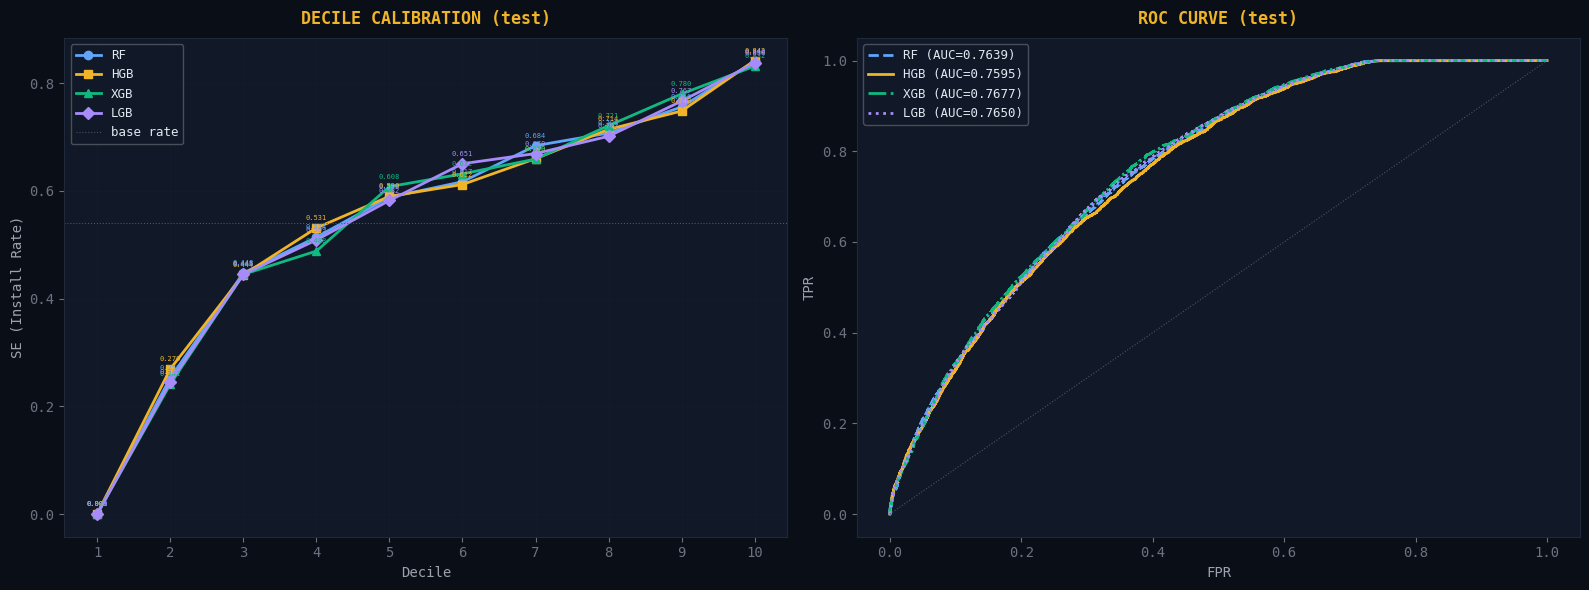

In [38]:
p_rf  = best_rf.predict(X_test)
p_hgb = best_hgb.predict(X_test)
p_xgb = best_xgb.predict(X_test)
p_lgb = best_lgb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Decile curves ──
ax = axes[0]
for preds, label, color, marker in [
    (p_rf,  "RF",  BLUE,   "o"),
    (p_hgb, "HGB", AMBER,  "s"),
    (p_xgb, "XGB", GREEN,  "^"),
    (p_lgb, "LGB", PURPLE, "D"),
]:
    tbl = _decile_table(y_test.values, preds)
    d = list(range(1, len(tbl) + 1))
    ax.plot(d, tbl["se"].values, f"{marker}-", color=color, linewidth=2,
            markersize=6, label=label)
    for j, se in enumerate(tbl["se"].values):
        ax.annotate(f"{se:.3f}", (j+1, se), fontsize=5, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points", color=color)

ax.axhline(y_test.mean(), color=GRAY, linestyle=":", linewidth=0.8, label="base rate")
ax.set(xlabel="Decile", ylabel="SE (Install Rate)")
ax.set_title("DECILE CALIBRATION (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.set_xticks(range(1, 11))
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)

# ── ROC ──
ax = axes[1]
for preds, label, color, ls in [
    (p_rf,  "RF",  BLUE,   "--"),
    (p_hgb, "HGB", AMBER,  "-"),
    (p_xgb, "XGB", GREEN,  "-."),
    (p_lgb, "LGB", PURPLE, ":"),
]:
    fpr, tpr, _ = roc_curve(y_test, preds)
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle=ls,
            label=f"{label} (AUC={a:.4f})")

ax.plot([0, 1], [0, 1], ":", color=GRAY, linewidth=0.8)
ax.set(xlabel="FPR", ylabel="TPR")
ax.set_title("ROC CURVE (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.legend(fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.show()

### 10b · Feature Importance (best RF)

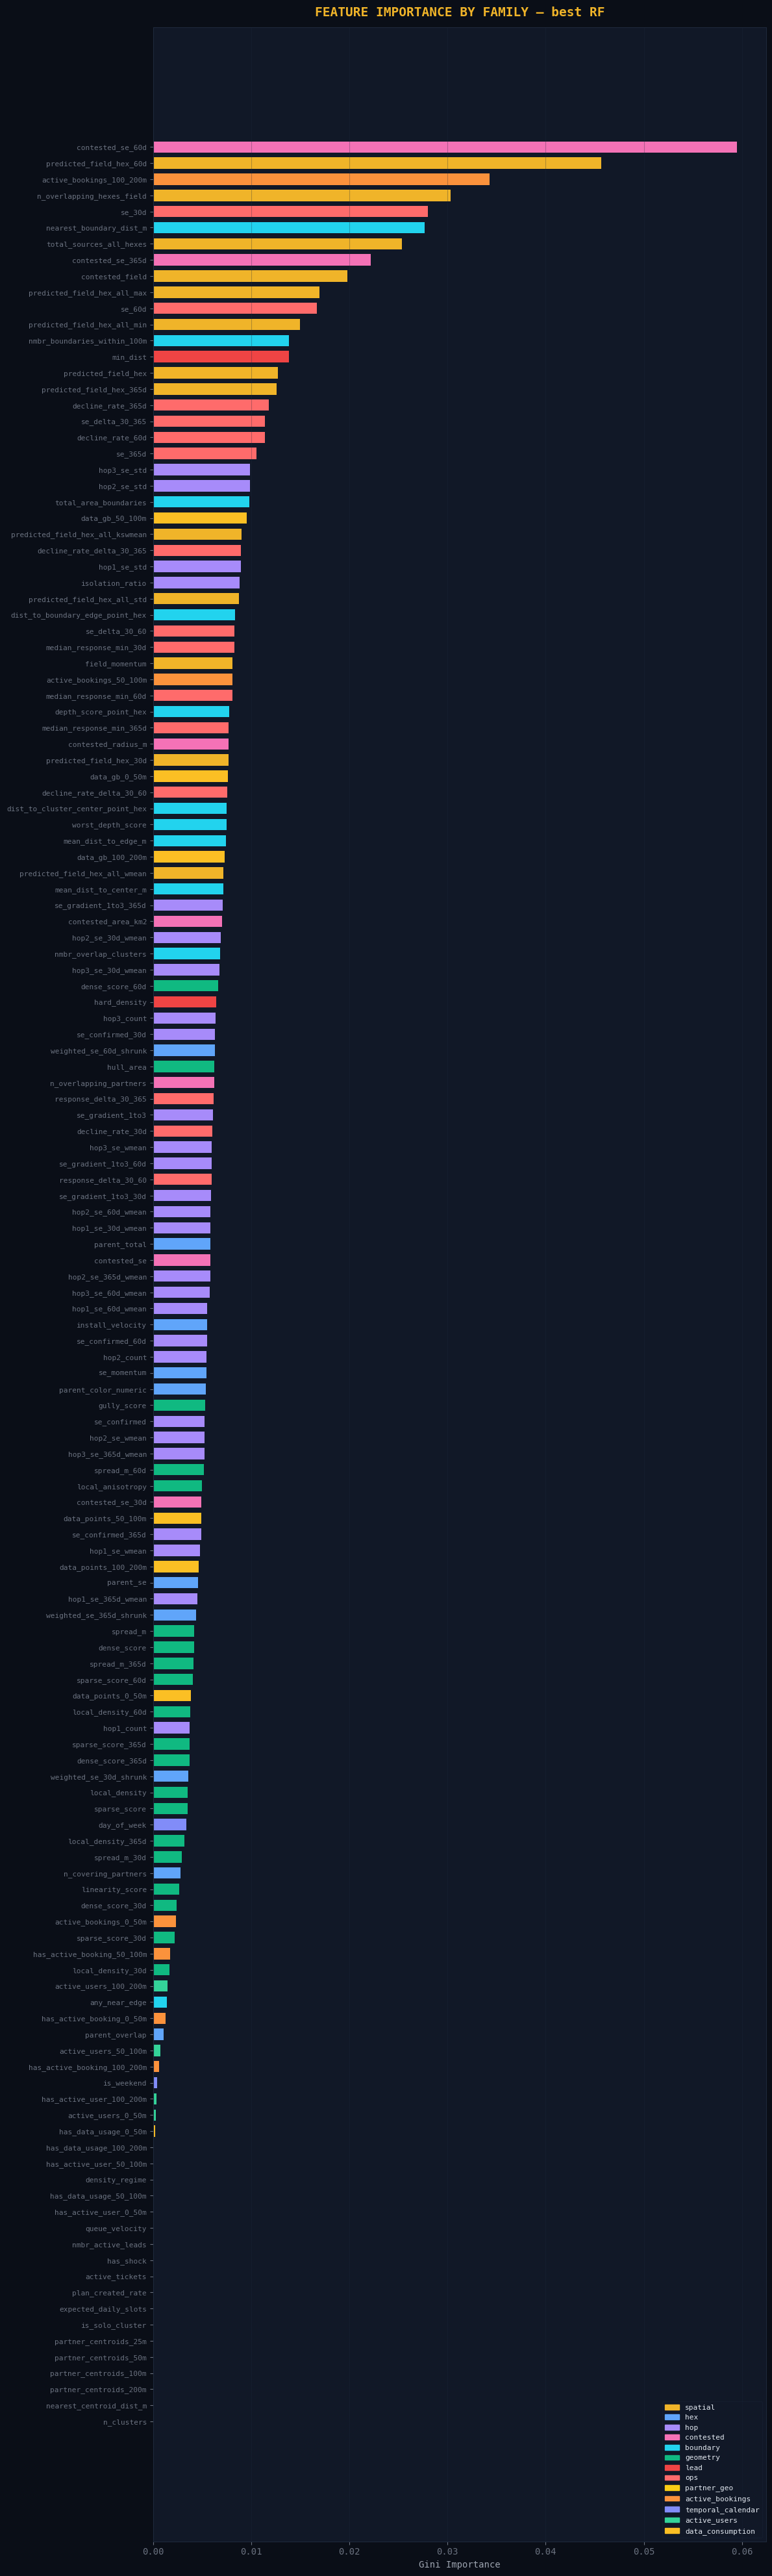

In [39]:
# ── Family → color lookup (derived from registry) ──
FAM_COLORS = {
    "spatial": AMBER, "hex": BLUE, "hop": PURPLE, "contested": PINK,
    "boundary": CYAN, "geometry": GREEN, "lead": RED, "ops": "#ff6b6b",
    "partner_geo": "#facc15",
    "active_bookings": "#fb923c",
    "temporal_calendar": "#818cf8",
    "active_users": "#34d399",
    "data_consumption": "#fbbf24",
}

imp = pd.Series(best_rf.feature_importances_, index=available).sort_values(ascending=True)
colors = [FAM_COLORS.get(family_map.get(f, ""), GRAY) for f in imp.index]

fig, ax = plt.subplots(figsize=(12, max(10, len(imp) * 0.28)))
ax.barh(range(len(imp)), imp.values, color=colors, height=0.7, edgecolor="none")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=8)
ax.set_xlabel("Gini Importance")
ax.set_title("FEATURE IMPORTANCE BY FAMILY — best RF",
             fontsize=14, fontweight="bold", color=AMBER, pad=12)
ax.grid(axis="x", alpha=0.3)

patches = [mpatches.Patch(color=c, label=k) for k, c in FAM_COLORS.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()


### 10c · Single Tree (depth=4 excerpt)

In [40]:
single_tree = best_rf.estimators_[0]
print(export_text(single_tree, feature_names=available, max_depth=4))

|--- contested_se_60d <= 0.62
|   |--- predicted_field_hex_365d <= -0.39
|   |   |--- nmbr_overlap_clusters <= 2.50
|   |   |   |--- decline_rate_60d <= 0.12
|   |   |   |   |--- predicted_field_hex_365d <= -0.39
|   |   |   |   |   |--- truncated branch of depth 11
|   |   |   |   |--- predicted_field_hex_365d >  -0.39
|   |   |   |   |   |--- value: [0.00]
|   |   |   |--- decline_rate_60d >  0.12
|   |   |   |   |--- active_bookings_100_200m <= 3.50
|   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |--- active_bookings_100_200m >  3.50
|   |   |   |   |   |--- truncated branch of depth 12
|   |   |--- nmbr_overlap_clusters >  2.50
|   |   |   |--- predicted_field_hex_all_max <= 0.00
|   |   |   |   |--- sparse_score_60d <= 0.84
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- sparse_score_60d >  0.84
|   |   |   |   |   |--- value: [0.29]
|   |   |   |--- predicted_field_hex_all_max >  0.00
|   |   |   |   |--- contested_se <= 0.19
|   |  

### 10d · Importance vs Correlation Scatter

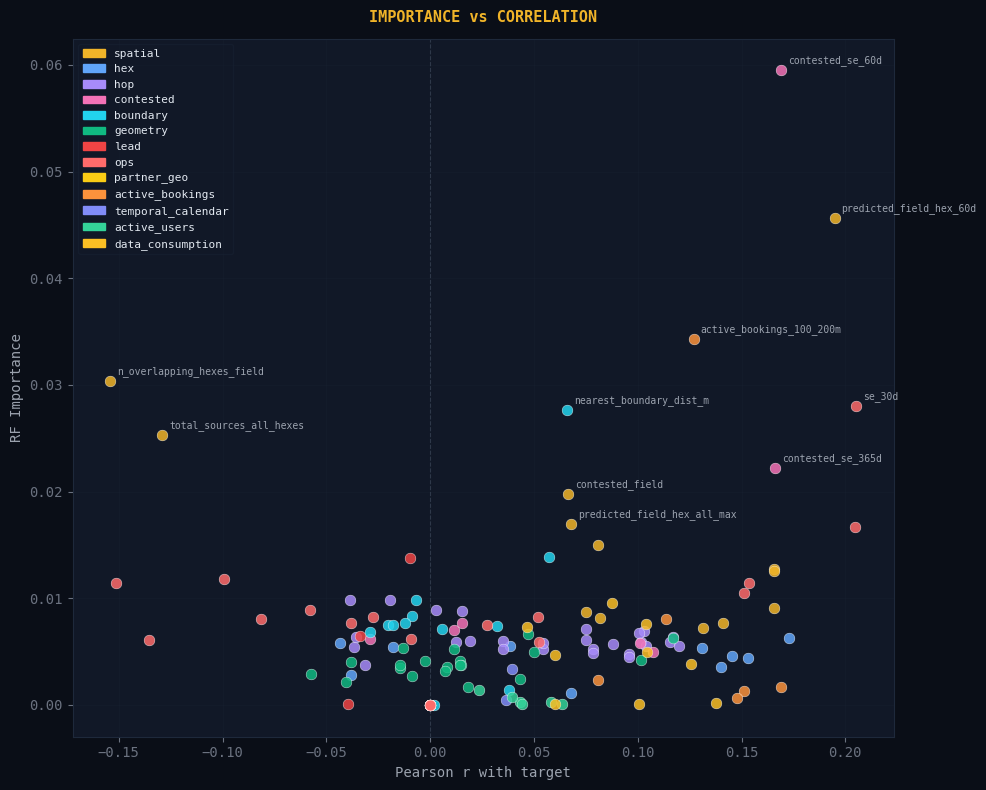

In [41]:
imp_desc = pd.Series(best_rf.feature_importances_, index=available)

fig, ax = plt.subplots(figsize=(10, 8))
for feat in imp_desc.index:
    c = FAM_COLORS.get(family_map.get(feat, ""), GRAY)
    ax.scatter(corr_target.get(feat, 0), imp_desc[feat],
               c=c, s=60, alpha=0.85, edgecolor="white", linewidth=0.3, zorder=3)

for feat in imp_desc.nlargest(10).index:
    if feat in corr_target.index:
        ax.annotate(feat, (corr_target[feat], imp_desc[feat]),
                    fontsize=7, color="#9ca3af", ha="left",
                    xytext=(5, 5), textcoords="offset points")

ax.axvline(0, color=GRAY, linestyle="--", linewidth=0.8, alpha=0.5)
ax.set(xlabel="Pearson r with target", ylabel="RF Importance")
ax.set_title("IMPORTANCE vs CORRELATION", fontsize=11, fontweight="bold", color=AMBER, pad=12)
ax.grid(alpha=0.2)

patches = [mpatches.Patch(color=c, label=k) for k, c in FAM_COLORS.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

## 11 · Comparison with Existing Scores

In [42]:
# Score the full dataset with all best models
df["rf_score"]  = best_rf.predict(df[available].fillna(FILL_VALUE))
df["hgb_score"] = best_hgb.predict(df[available].fillna(FILL_VALUE))
df["xgb_score"] = best_xgb.predict(df[available].fillna(FILL_VALUE))
df["lgb_score"] = best_lgb.predict(df[available].fillna(FILL_VALUE))

COMPARE_COLS = ["rf_score", "hgb_score", "xgb_score", "lgb_score", "composite_score", "spatial_shrunk"]

print(f"{'Score':25s}  {'AUC':>7s}  {'gap_pp':>7s}  {'D1_SE':>7s}  {'D10_SE':>7s}  {'composite':>10s}  {'mono':>5s}")
print("-" * 82)
for col in COMPARE_COLS:
    if col in df.columns:
        m = score_column(df, col)
        print(f"{col:25s}  {m['auc']:7.4f}  {m['gap_pp']:7.2f}  "
              f"{m['d1_se']:7.4f}  {m['d10_se']:7.4f}  "
              f"{m['composite']:10.2f}  {str(m['mono']):>5s}")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:parent_overlap: object

## 12 · Concordance-Gated Label Cleaning — Setup

Ambiguous leads (INDETERMINATE / HANGING) are spatially matched against
hard-labelled training decisions using a BallTree (100 m radius, k ≥ 3).
If the local concordance (fraction agreeing with the majority label) exceeds
the threshold, the lead is kept; otherwise dropped.

**Thresholds swept**: 0.60 → 0.90 (step 0.05)


In [ ]:
# ── Load raw test decisions (for hard vs ambiguous split) ──
from data_lib.data_fetch.get_data import get_test_data
import data_lib.config as config

df_test_raw = get_test_data(config.TEST_START_DATE, config.TEST_END_DATE)
mobile_decisions = df_test_raw.groupby("mobile")["final_decision"].first()
hard_mobiles  = mobile_decisions[mobile_decisions.isin(["INSTALLED", "DECLINED"])].index
ambig_mobiles = mobile_decisions[mobile_decisions.isin(["INDETERMINATE", "HANGING"])].index
print(f"Hard: {len(hard_mobiles)}  |  Ambiguous: {len(ambig_mobiles)}")


In [ ]:
# ── Build BallTree on hard training decisions ──
from sklearn.neighbors import BallTree as _ConcBallTree

df_train_h5 = pd.read_hdf(TRAIN_DATA_PATH, "df")
hard_train = df_train_h5[df_train_h5["final_decision"].isin(["INSTALLED", "DECLINED"])].copy()
hard_train["is_install"] = (hard_train["final_decision"] == "INSTALLED").astype(int)

train_rad    = np.radians(hard_train[["latitude", "longitude"]].values)
train_labels = hard_train["is_install"].values
conc_ball_tree = _ConcBallTree(train_rad, metric="haversine")

# ── Query ambiguous leads once — reuse for all thresholds ──
ambig_in_df = df[df["mobile"].isin(ambig_mobiles)].copy()
radius_rad  = RADIUS_M / 6_371_000
ambig_rad   = np.radians(ambig_in_df[["latitude", "longitude"]].values)
conc_idx_list, _ = conc_ball_tree.query_radius(ambig_rad, r=radius_rad, return_distance=True)
print(f"Ambiguous in scored df: {len(ambig_in_df)}")
print(f"Hard train leads used for BallTree: {len(hard_train):,}")


In [ ]:
def filter_by_concordance(conc_thresh):
    """Return filtered df for a given concordance threshold."""
    keep_mask = []
    for idxs in conc_idx_list:
        if len(idxs) < K_MIN:
            keep_mask.append(False)
            continue
        frac_pos = train_labels[idxs].mean()
        keep_mask.append(max(frac_pos, 1 - frac_pos) >= conc_thresh)
    keep_mask = np.array(keep_mask)
    concordant = ambig_in_df.loc[keep_mask, "mobile"].values
    keep = set(hard_mobiles) | set(concordant)
    df_filt = df[df["mobile"].isin(keep)].copy()
    n_ambig = len(concordant)
    return df_filt, n_ambig

# Quick sanity check
for ct in CONCORDANCE_THRESHOLDS:
    _, n_a = filter_by_concordance(ct)
    print(f"  C={ct:.2f} → ambig kept: {n_a}")


### 12b · Concordance Evaluation Utility

Extended `eval_model` that records per-decile SE and counts
(needed for the concordance leaderboard CSV).


In [ ]:
def eval_model_conc(model, X_tr, y_tr, X_te, y_te):
    """Evaluate a fitted model — concordance variant with full decile detail."""
    p_train = model.predict(X_tr)
    p_test  = model.predict(X_te)

    auc_train = roc_auc_score(y_tr, p_train)
    auc_test  = roc_auc_score(y_te, p_test)

    edf = pd.DataFrame({"y": y_te.values, "p": p_test})
    edf["decile"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
    tbl = (edf.groupby("decile")
              .agg(n=("y", "count"), inst=("y", "sum"))
              .reindex(range(1, 11)))
    tbl["se"] = tbl["inst"] / tbl["n"]

    d1_se  = tbl.loc[1, "se"]
    d10_se = tbl.loc[10, "se"]
    gap_pp = (d10_se - d1_se) * 100
    mono   = bool((tbl["se"].diff().dropna() >= 0).all())
    composite = 200 * auc_test + gap_pp

    result = dict(
        auc_train=round(auc_train, 4), auc_test=round(auc_test, 4),
        gap_pp=round(gap_pp, 2), d1_se=round(d1_se, 4), d10_se=round(d10_se, 4),
        mono=mono, composite=round(composite, 2),
    )
    for i in range(1, 11):
        result[f"d{i}_se"] = round(tbl.loc[i, "se"], 4) if pd.notna(tbl.loc[i, "se"]) else None
        result[f"d{i}_n"]  = int(tbl.loc[i, "n"]) if pd.notna(tbl.loc[i, "n"]) else 0
    return result


## 13 · Concordance Sweep — All Models × All Thresholds

Loops over every concordance threshold (0.60 → 0.90).  
For each threshold, applies spatial label cleaning to the **train set only**,
then runs the full hyperparameter sweep for **RF, HGB, XGB, and LGB**.

Test set is always the unfiltered split — ensures comparability.


In [ ]:
import json as _json_conc

# ── Pre-sample combos (same seed → reproducible across thresholds) ──
np.random.seed(RANDOM_STATE)

_all_rf  = list(iterproduct(*RF_GRID.values()))
_all_hgb = list(iterproduct(*HGB_GRID.values()))
_all_xgb = list(iterproduct(*XGB_GRID.values()))
_all_lgb = list(iterproduct(*LGB_GRID.values()))

_rf_idx  = np.random.choice(len(_all_rf),  min(N_RANDOM_SAMPLES, len(_all_rf)),  replace=False)
_hgb_idx = np.random.choice(len(_all_hgb), min(N_RANDOM_SAMPLES, len(_all_hgb)), replace=False)
_xgb_idx = np.random.choice(len(_all_xgb), min(N_RANDOM_SAMPLES, len(_all_xgb)), replace=False)
_lgb_idx = np.random.choice(len(_all_lgb), min(N_RANDOM_SAMPLES, len(_all_lgb)), replace=False)

sampled_rf_conc  = [_all_rf[i]  for i in _rf_idx]
sampled_hgb_conc = [_all_hgb[i] for i in _hgb_idx]
sampled_xgb_conc = [_all_xgb[i] for i in _xgb_idx]
sampled_lgb_conc = [_all_lgb[i] for i in _lgb_idx]

print(f"RF : {len(_all_rf):>6,} → {len(sampled_rf_conc)}")
print(f"HGB: {len(_all_hgb):>6,} → {len(sampled_hgb_conc)}")
print(f"XGB: {len(_all_xgb):>6,} → {len(sampled_xgb_conc)}")
print(f"LGB: {len(_all_lgb):>6,} → {len(sampled_lgb_conc)}")


In [ ]:
# ── Sweep runners for concordance loop ──

def _run_conc_rf(X_tr, y_tr, X_te, y_te):
    rows, best_comp, best_mdl = [], -np.inf, None
    rf_keys = list(RF_GRID.keys())
    for combo in tqdm(sampled_rf_conc, desc="RF"):
        params = dict(zip(rf_keys, combo))
        m = RandomForestRegressor(**params, **RF_FIXED)
        m.fit(X_tr, y_tr)
        ev = eval_model_conc(m, X_tr, y_tr, X_te, y_te)
        row = {"model": "RF", "params": _json_conc.dumps(params),
               **{k: ev[k] for k in ev}}
        rows.append(row)
        if ev["composite"] > best_comp:
            best_comp, best_mdl = ev["composite"], m
            print(f"  RF  best: auc(val)={ev['auc_test']:.4f} gap={ev['gap_pp']:.2f} comp={ev['composite']:.2f}")
    return rows, best_mdl


def _run_conc_hgb(X_tr, y_tr, X_te, y_te):
    rows, best_comp, best_mdl = [], -np.inf, None
    hgb_keys = list(HGB_GRID.keys())
    for combo in tqdm(sampled_hgb_conc, desc="HGB"):
        params = dict(zip(hgb_keys, combo))
        m = HistGradientBoostingRegressor(**params, **HGB_FIXED)
        m.fit(X_tr, y_tr)
        ev = eval_model_conc(m, X_tr, y_tr, X_te, y_te)
        row = {"model": "HGB", "params": _json_conc.dumps({**params, "n_iter": m.n_iter_}),
               **{k: ev[k] for k in ev}}
        rows.append(row)
        if ev["composite"] > best_comp:
            best_comp, best_mdl = ev["composite"], m
            print(f"  HGB best: auc(val)={ev['auc_test']:.4f} gap={ev['gap_pp']:.2f} comp={ev['composite']:.2f}")
    return rows, best_mdl


def _run_conc_xgb(X_tr, y_tr, X_te, y_te):
    rows, best_comp, best_mdl = [], -np.inf, None
    xgb_keys = list(XGB_GRID.keys())
    for combo in tqdm(sampled_xgb_conc, desc="XGB"):
        params = dict(zip(xgb_keys, combo))
        m = xgb.XGBRegressor(**params, **XGB_FIXED)
        m.fit(X_tr, y_tr)
        ev = eval_model_conc(m, X_tr, y_tr, X_te, y_te)
        row = {"model": "XGB", "params": _json_conc.dumps(params),
               **{k: ev[k] for k in ev}}
        rows.append(row)
        if ev["composite"] > best_comp:
            best_comp, best_mdl = ev["composite"], m
            print(f"  XGB best: auc(val)={ev['auc_test']:.4f} gap={ev['gap_pp']:.2f} comp={ev['composite']:.2f}")
    return rows, best_mdl


def _run_conc_lgb(X_tr, y_tr, X_te, y_te):
    rows, best_comp, best_mdl = [], -np.inf, None
    lgb_keys = list(LGB_GRID.keys())
    for combo in tqdm(sampled_lgb_conc, desc="LGB"):
        params = dict(zip(lgb_keys, combo))
        m = lgb.LGBMRegressor(**params, **LGB_FIXED)
        m.fit(X_tr, y_tr)
        ev = eval_model_conc(m, X_tr, y_tr, X_te, y_te)
        row = {"model": "LGB", "params": _json_conc.dumps(params),
               **{k: ev[k] for k in ev}}
        rows.append(row)
        if ev["composite"] > best_comp:
            best_comp, best_mdl = ev["composite"], m
            print(f"  LGB best: auc(val)={ev['auc_test']:.4f} gap={ev['gap_pp']:.2f} comp={ev['composite']:.2f}")
    return rows, best_mdl


In [ ]:
# ══════════════════════════════════════════════════════════════
# CONCORDANCE SWEEP LOOP
# ══════════════════════════════════════════════════════════════

all_conc_results = []
saved_models = {}

# ── Build the FULL unfiltered train/test split ONCE ──
X_full = df[available].copy().fillna(FILL_VALUE)
y_full = df[TARGET].copy()
_mask_full = y_full.notna()
X_full, y_full = X_full[_mask_full], y_full[_mask_full]
for c in X_full.select_dtypes(include=["object", "category"]).columns:
    X_full[c] = pd.to_numeric(X_full[c], errors="coerce").fillna(FILL_VALUE)
X_full = X_full.astype(np.float64)

# ── 3-way split: 60% train / 10% val / 30% test ──
X_tv_full, X_te_full, y_tv_full, y_te_full = train_test_split(
    X_full, y_full,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_full.astype(int),
)
X_tr_full, X_val_full, y_tr_full, y_val_full = train_test_split(
    X_tv_full, y_tv_full,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_STATE,
    stratify=y_tv_full.astype(int),
)
print(f"Full split — train: {len(X_tr_full)}  val: {len(X_val_full)}  test: {len(X_te_full)}")
print(f"Train SE: {y_tr_full.mean():.4f}  Val SE: {y_val_full.mean():.4f}  Test SE (fixed): {y_te_full.mean():.4f}")

for conc in CONCORDANCE_THRESHOLDS:
    print(f"\n{'='*70}")
    print(f"  CONCORDANCE = {conc:.2f}")
    print(f"{'='*70}")

    # ── Concordance filter ONLY on train indices ──
    df_c, n_ambig = filter_by_concordance(conc)
    conc_idx = df_c.index.intersection(X_tr_full.index)
    X_tr_c = X_tr_full.loc[conc_idx]
    y_tr_c = y_tr_full.loc[conc_idx]

    print(f"  train={len(X_tr_c)} (filtered)  val={len(X_val_full)}  test={len(X_te_full)} (held out)  ambig_added={n_ambig}")
    print(f"  train SE: {y_tr_c.mean():.4f}")

    # ── Run all 4 sweeps (select on VAL, test held out) ──
    rf_rows,  best_rf_c  = _run_conc_rf(X_tr_c, y_tr_c, X_val_full, y_val_full)
    hgb_rows, best_hgb_c = _run_conc_hgb(X_tr_c, y_tr_c, X_val_full, y_val_full)
    xgb_rows, best_xgb_c = _run_conc_xgb(X_tr_c, y_tr_c, X_val_full, y_val_full)
    lgb_rows, best_lgb_c = _run_conc_lgb(X_tr_c, y_tr_c, X_val_full, y_val_full)

    for r in rf_rows + hgb_rows + xgb_rows + lgb_rows:
        r["concordance"] = conc
    all_conc_results.extend(rf_rows + hgb_rows + xgb_rows + lgb_rows)

    # ── Save best model per type ──
    for tag, mdl in [("RF", best_rf_c), ("HGB", best_hgb_c),
                     ("XGB", best_xgb_c), ("LGB", best_lgb_c)]:
        if mdl is not None:
            path = f"{MODEL_DIR}/{tag}_conc{conc:.2f}.joblib"
            joblib.dump(mdl, path)
            saved_models[(conc, tag)] = path
            print(f"  saved {path}")

print(f"\nTotal concordance experiments: {len(all_conc_results)}")


## 14 · Concordance Combined Leaderboard


In [ ]:
conc_results_df = pd.DataFrame(all_conc_results)
conc_results_df = conc_results_df.sort_values("composite", ascending=False).reset_index(drop=True)

metric_cols = ["concordance", "model", "params", "auc_train", "auc_test",
               "gap_pp", "d1_se", "d10_se", "mono", "composite"]
decile_cols = [f"d{d}_se" for d in range(1, 11)] + [f"d{d}_n" for d in range(1, 11)]
report_cols = [c for c in metric_cols + decile_cols if c in conc_results_df.columns]

conc_results_df[report_cols].to_csv("../reports/concordance_sweep_report.csv", index=False)
print(f"Saved {len(conc_results_df)} rows to concordance_sweep_report.csv")

# ── Top 20 overall ──
print("\n" + "="*100)
print("  CONCORDANCE SWEEP — TOP 20 OVERALL")
print("="*100)
print(conc_results_df.head(20)[["concordance", "model", "auc_test", "gap_pp",
                                 "d1_se", "d10_se",
                                 "composite", "mono", "params"]].to_string())


In [ ]:
# ── Top 10 per concordance threshold ──
for conc in CONCORDANCE_THRESHOLDS:
    sub = conc_results_df[conc_results_df["concordance"] == conc].head(10)
    print(f"\n── C={conc:.2f} top 10 ──")
    print(sub[["model", "auc_test", "gap_pp", "d1_se", "d10_se", "composite", "mono", "params"]].to_string(index=False))


## 15 · Concordance Comparison Summary


In [ ]:
conc_summary = (
    conc_results_df
    .groupby(["concordance", "model"])
    .agg(
        best_composite=("composite", "max"),
        best_auc=("auc_test", "max"),
        best_gap=("gap_pp", "max"),
        median_composite=("composite", "median"),
        n_mono=("mono", "sum"),
        n_runs=("mono", "count"),
    )
    .reset_index()
)
conc_summary["mono_pct"] = (conc_summary["n_mono"] / conc_summary["n_runs"] * 100).round(1)

print("CONCORDANCE × MODEL SUMMARY")
print("="*110)
print(conc_summary.to_string(index=False))


In [ ]:
# ── Plot: best composite by concordance threshold per model ──
fig, ax = plt.subplots(figsize=(12, 6))
model_colors = {"RF": BLUE, "HGB": AMBER, "XGB": GREEN, "LGB": PURPLE}

for model_name, color in model_colors.items():
    sub = conc_summary[conc_summary["model"] == model_name].sort_values("concordance")
    ax.plot(sub["concordance"], sub["best_composite"], "o-", color=color,
            linewidth=2, markersize=8, label=model_name)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['best_composite']:.1f}",
                    (row["concordance"], row["best_composite"]),
                    fontsize=7, ha="center", va="bottom",
                    xytext=(0, 6), textcoords="offset points", color=color)

ax.set(xlabel="Concordance Threshold", ylabel="Best Composite (200×AUC + gap_pp)")
ax.set_title("CONCORDANCE SWEEP — BEST COMPOSITE BY THRESHOLD",
             fontsize=13, fontweight="bold", color=AMBER, pad=12)
ax.legend(fontsize=10, framealpha=0.3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 16 · Best Concordance Model — Deep Dive


In [ ]:
# ── Pick overall best concordance + model ──
best_conc_row = conc_results_df.iloc[0]
best_conc_val = best_conc_row["concordance"]
best_conc_type = best_conc_row["model"]
best_conc_path = saved_models[(best_conc_val, best_conc_type)]
best_conc_model = joblib.load(best_conc_path)

print(f"Best (selected on val): {best_conc_type} @ concordance={best_conc_val:.2f}  composite(val)={best_conc_row['composite']}")
print(f"  AUC={best_conc_row['auc_test']}  gap_pp={best_conc_row['gap_pp']}  "
      f"D1={best_conc_row['d1_se']}  D10={best_conc_row['d10_se']}  mono={best_conc_row['mono']}")
print(f"  params: {best_conc_row['params']}")

# ── Final evaluation on held-out TEST set ──
_p_te = best_conc_model.predict(X_te_full)
_auc_te = roc_auc_score(y_te_full, _p_te)
_edf_te = pd.DataFrame({"y": y_te_full.values, "p": _p_te})
_edf_te["d"] = pd.qcut(_edf_te["p"], q=10, labels=False, duplicates="drop") + 1
_tbl_te = _edf_te.groupby("d").agg(n=("y","count"), inst=("y","sum")).reindex(range(1,11))
_tbl_te["se"] = _tbl_te["inst"] / _tbl_te["n"]
_d1  = _tbl_te.loc[1,"se"]
_d10 = _tbl_te.loc[10,"se"]
_gap = (_d10 - _d1) * 100
print(f"\n── HOLDOUT TEST (30%) ──")
print(f"  AUC={_auc_te:.4f}  gap_pp={_gap:.2f}  D1={_d1:.4f}  D10={_d10:.4f}  composite={200*_auc_te + _gap:.2f}")


In [ ]:
# ── Decile & ROC for best concordance model ──
p_conc_best = best_conc_model.predict(X_te_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decile
ax = axes[0]
edf = pd.DataFrame({"y": y_te_full.values, "p": p_conc_best})
edf["d"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
tbl = edf.groupby("d").agg(n=("y", "count"), inst=("y", "sum"))
tbl["se"] = tbl["inst"] / tbl["n"]
d_range = list(range(1, len(tbl) + 1))
ax.plot(d_range, tbl["se"].values, "o-", color=AMBER, lw=2, ms=6)
for j, se in enumerate(tbl["se"].values):
    ax.annotate(f"{se:.3f}", (j+1, se), fontsize=6, ha="center",
                va="bottom", xytext=(0, 5), textcoords="offset points", color=AMBER)
ax.axhline(y_te_full.mean(), color=GRAY, ls=":", lw=0.8, label="base rate")
ax.set(xlabel="Decile", ylabel="SE",
       title=f"DECILE — {best_conc_type} C={best_conc_val:.2f}")
ax.set_xticks(range(1, 11))
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# ROC
ax = axes[1]
fpr, tpr, _ = roc_curve(y_te_full, p_conc_best)
roc_auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color=AMBER, lw=2, label=f"{best_conc_type} AUC={roc_auc_val:.4f}")
ax.plot([0, 1], [0, 1], ":", color=GRAY, lw=0.8)
ax.set(xlabel="FPR", ylabel="TPR",
       title=f"ROC — {best_conc_type} C={best_conc_val:.2f}")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 17 · Saved Concordance Models


In [ ]:
print(f"{'Concordance':>12}  {'Model':>5}  {'Path'}")
print("-" * 70)
for (conc, tag), path in sorted(saved_models.items()):
    print(f"{conc:>12.2f}  {tag:>5}  {path}")
print(f"\nTotal models saved: {len(saved_models)}")
